In [1]:
# imports
%matplotlib qt
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.signal import find_peaks

mne.viz.set_browser_backend("qt")


def need(*names):  # проверяет, что нужные переменные уже созданы
    missing = [name for name in names if name not in globals()]
    if missing:
        raise RuntimeError(f"Нужны переменные: {missing}")


def as_float(value, default=np.nan):  # переводит значение в число или default
    try:
        value = float(value)
    except Exception:
        return default
    return value if np.isfinite(value) else default


def idx_at(axis, value):  # находит индекс ближайшего времени
    return int(np.argmin(np.abs(axis - value)))


In [2]:
# загрузка MATLAB-записи из папки проекта data/raw

project_root = Path.cwd()  # папка запуска ноутбука
if project_root.name == "notebooks":
    project_root = project_root.parent

outputs_dir = project_root / "outputs"  # результаты
annotations_dir = outputs_dir / "annotations"  # аннотации
figures_dir = outputs_dir / "figures"  # графики

for folder in [annotations_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)

# загрузка из папки проекта data/raw
data_raw = project_root / "data" / "raw"
mat_path = data_raw / "pig_4_9_14_day_after_SCI.mat"

if not mat_path.exists():
    raise FileNotFoundError(f"Файл не найден: {mat_path}")

# MATLAB хранит каналы каждого из четырёх блоков последовательно в data.
mat = loadmat(
    mat_path,
    variable_names=["data", "datastart", "dataend", "titles", "samplerate"],
    simplify_cells=True,
)
data = mat["data"].ravel()
starts = mat["datastart"].astype(int) - 1  # индексы MATLAB начинаются с 1
ends = mat["dataend"].astype(int)
ch_names = [name.strip() for name in mat["titles"]]
sfreq = float(mat["samplerate"][0, 0])

blocks = []
for block_idx in range(starts.shape[1]):
    block_data = np.vstack([
        data[starts[ch_idx, block_idx]:ends[ch_idx, block_idx]]
        for ch_idx in range(len(ch_names))
    ])
    info = mne.create_info(ch_names, sfreq, ch_types="emg")
    blocks.append(mne.io.RawArray(block_data, info, verbose=False))

# Сохраняем границы исходных блоков как boundary-аннотации MNE.
raw = mne.concatenate_raws(blocks, preload=True, verbose=False)
raw_original = raw.copy()

# параметры влияют только на отображение, данные остаются в вольтах
emg_browser_kwargs = dict(
    duration=1.0,
    n_channels=min(8, len(raw.ch_names)),
    scalings={"emg": 8.0779357},  # V; 8077935.7 µV from the browser settings
)

sfreq = raw.info["sfreq"]
duration_s = raw.n_times / sfreq

print("File:", mat_path.name)
print("Channels:", len(raw.ch_names))
print("sfreq:", sfreq)
print("Duration, s:", round(duration_s, 2))
print("First channels:", raw.ch_names[:10])


Opening raw data file /Users/user/Documents/emg-lr-segmentation/data/raw/3_3_rhythm_late_responses_raw.fif...
Isotrak not found
    Range : 0 ... 164899 =      0.000 ...    41.225 secs
Ready.
Reading 0 ... 164899  =      0.000 ...    41.225 secs...
File: 3_3_rhythm_late_responses_raw.fif
Channels: 7
sfreq: 4000.0
Duration, s: 41.22
First channels: ['EMG1', 'EMG2', 'EMG3', 'EMG4', 'EMG5', 'EMG6', 'EMG7']


In [3]:
# посмотреть сырую запись в MNE 
raw.plot(**emg_browser_kwargs, block=False)


Using qt as 2D backend.


In [ ]:
# авторазметка стимулов

stim_ch = "Art"
stim_label = "Stimulus_Auto"
analysis_ch = "GM Right"
expected_isi_ms = 500.0
isi_tolerance_ms = 10.0
stim_noise_k = 3.0  # permissive threshold; cadence filters false candidates
max_cadence_gap_ms = 20000.0  # longest supported gap inside a train

missing_channels = [ch for ch in [stim_ch, analysis_ch] if ch not in raw.ch_names]
if missing_channels:
    raise ValueError(f"Каналы не найдены: {missing_channels}")

sfreq = raw.info["sfreq"]
expected_isi_samples = int(round(expected_isi_ms / 1000 * sfreq))
isi_tolerance_samples = int(round(isi_tolerance_ms / 1000 * sfreq))
stim_min_distance_samples = expected_isi_samples - isi_tolerance_samples
if stim_min_distance_samples <= 0:
    raise ValueError("Допуск ISI должен быть меньше ожидаемого ISI")

art = raw.copy().pick([stim_ch]).get_data()[0]
art_abs = np.abs(art - np.median(art))
art_median = np.median(art_abs)
art_noise = 1.4826 * np.median(np.abs(art_abs - art_median))
peak_threshold = art_median + stim_noise_k * art_noise

# Scan the concatenated recording globally. Cadence is checked locally, so separate
# stimulation trains may start at different phases without using MATLAB block IDs.
threshold_samples, _ = find_peaks(art_abs, height=peak_threshold)
candidate_samples, candidate_properties = find_peaks(
    art_abs, height=peak_threshold, distance=stim_min_distance_samples
)
max_cadence_steps = int(round(max_cadence_gap_ms / expected_isi_ms))

cadence_supported = []
for sample in candidate_samples:
    deltas = np.abs(candidate_samples - sample)
    steps = np.rint(deltas / expected_isi_samples).astype(int)
    cadence_error = np.abs(deltas - steps * expected_isi_samples)
    has_neighbor = np.any(
        (steps >= 1) & (steps <= max_cadence_steps)
        & (cadence_error <= isi_tolerance_samples)
    )
    cadence_supported.append(has_neighbor)
cadence_samples = candidate_samples[np.asarray(cadence_supported, dtype=bool)]

# Split global candidates into local cadence trains; no MATLAB block information is used.
cadence_trains = []
if len(cadence_samples):
    train_start = 0
    for idx, gap in enumerate(np.diff(cadence_samples)):
        gap_steps = int(round(gap / expected_isi_samples))
        gap_error = abs(gap - gap_steps * expected_isi_samples)
        if gap_steps < 1 or gap_steps > max_cadence_steps or gap_error > 2 * isi_tolerance_samples:
            cadence_trains.append(cadence_samples[train_start:idx + 1])
            train_start = idx + 1
    cadence_trains.append(cadence_samples[train_start:])
cadence_trains = [train for train in cadence_trains if len(train) >= 2]

cadence_added_samples = []
final_parts = []
for train in cadence_trains:
    final_parts.append(train)
    for left, right in zip(train[:-1], train[1:]):
        n_steps = int(round((right - left) / expected_isi_samples))
        for step in range(1, n_steps):
            predicted = left + step * expected_isi_samples
            lo = max(0, predicted - isi_tolerance_samples)
            hi = min(len(art_abs), predicted + isi_tolerance_samples + 1)
            recovered = lo + int(np.argmax(art_abs[lo:hi]))
            cadence_added_samples.append(recovered)

if cadence_added_samples:
    final_parts.append(np.asarray(cadence_added_samples, dtype=int))
stim_samples = np.unique(np.concatenate(final_parts)).astype(int) if final_parts else np.array([], dtype=int)
if len(stim_samples) == 0:
    raise RuntimeError(f"Не найдено ни одного стимула на {stim_ch}")

funnel_df = pd.DataFrame([
    {"stage": "Amplitude threshold", "output_count": len(threshold_samples), "removed": np.nan, "added": 0},
    {"stage": "Minimum ISI distance", "output_count": len(candidate_samples), "removed": len(threshold_samples) - len(candidate_samples), "added": 0},
    {"stage": "Local cadence support", "output_count": len(cadence_samples), "removed": len(candidate_samples) - len(cadence_samples), "added": 0},
    {"stage": "Cadence gap completion", "output_count": len(stim_samples), "removed": 0, "added": len(stim_samples) - len(cadence_samples)},
    {"stage": "Final annotations", "output_count": len(stim_samples), "removed": 0, "added": 0},
])

# Audit saved manual QC labels against every detector stage.
manual_qc_path = annotations_dir / "stimulus_manual_qc-annot.fif"
manual_audit_rows = []
if manual_qc_path.exists():
    manual_qc = mne.read_annotations(manual_qc_path)
    manual_mask = np.char.find(np.asarray(manual_qc.description, dtype=str), "missing") >= 0
    manual_samples = np.rint(np.asarray(manual_qc.onset)[manual_mask] * sfreq).astype(int)

    def stage_has_sample(stage_samples, sample):
        return bool(len(stage_samples) and np.min(np.abs(stage_samples - sample)) <= isi_tolerance_samples)

    for sample in manual_samples:
        lo = max(0, sample - isi_tolerance_samples)
        hi = min(len(art_abs), sample + isi_tolerance_samples + 1)
        strength_x_noise = (np.max(art_abs[lo:hi]) - art_median) / art_noise
        passes = {
            "amplitude": stage_has_sample(threshold_samples, sample),
            "min_distance": stage_has_sample(candidate_samples, sample),
            "cadence_support": stage_has_sample(cadence_samples, sample),
            "final": stage_has_sample(stim_samples, sample),
        }
        first_failed = next((name for name, passed in passes.items() if not passed), "none")
        manual_audit_rows.append({
            "time_s": sample / sfreq, "strength_x_noise": strength_x_noise,
            **passes, "first_failed_stage": first_failed,
        })
manual_audit_df = pd.DataFrame(manual_audit_rows)
old_ann = raw.annotations
keep = np.asarray(old_ann.description) != stim_label
clean_ann = mne.Annotations(old_ann.onset[keep], old_ann.duration[keep], np.asarray(old_ann.description)[keep], orig_time=old_ann.orig_time)
stim_ann = mne.Annotations(stim_samples / sfreq, np.zeros(len(stim_samples)), [stim_label] * len(stim_samples), orig_time=old_ann.orig_time)
raw.set_annotations(clean_ann + stim_ann)

print(f"Threshold {stim_ch} abs ({stim_noise_k:.1f} x noise): {peak_threshold:.6g}")
print("Expected/tolerance/min distance, samples:", expected_isi_samples, isi_tolerance_samples, stim_min_distance_samples)
print("Cadence trains (start, stop, count):")
display(pd.DataFrame([
    {"start_s": train[0] / sfreq, "stop_s": train[-1] / sfreq, "anchors": len(train)}
    for train in cadence_trains
]))
display(funnel_df)
if len(manual_audit_df):
    print("Saved manual-label audit:")
    display(manual_audit_df)
print("Stimulus_Auto count:", int(np.sum(raw.annotations.description == stim_label)))


In [ ]:
# QC: raw browser со всеми каналами и Stimulus_Auto-аннотациями

stim_times_s = (stim_samples - raw.first_samp) / raw.info["sfreq"]
qc_start_s = max(0.0, float(stim_times_s[0] - 0.5))
print(f"Opening raw browser at {qc_start_s:.3f} s with {len(raw.ch_names)} channels.")
raw.plot(
    start=qc_start_s,
    duration=5.0,
    n_channels=len(raw.ch_names),
    scalings=emg_browser_kwargs["scalings"],
    title="Stimulus QC — all channels with Stimulus_Auto annotations",
    block=False,
)


Used Annotations descriptions: ['Stimulus_Auto']
n stimuli: 1247
ISI median, ms: 33.0
ISI mean, ms: 33.05477528089887
ISI std, ms: 0.3527853933639948
ISI min/max, ms: 27.25 38.75
ISI 1/99 percentiles, ms: [33.   33.25]


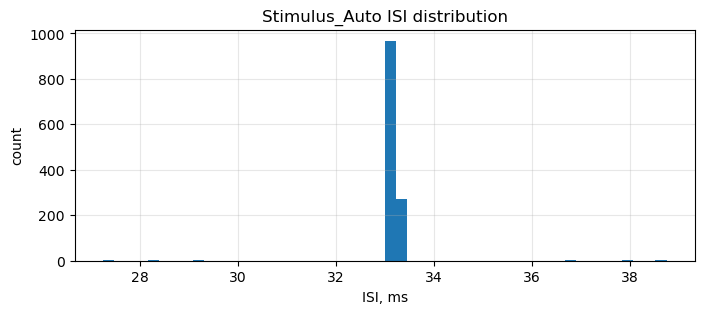

In [ ]:
# Распределение ISI

block_isi_ms = [
    np.diff(samples) / sfreq * 1000
    for samples in accepted_samples_by_block
    if len(samples) > 1
]
if not block_isi_ms:
    raise RuntimeError("Недостаточно стимулов для расчёта ISI")

isi_ms = np.concatenate(block_isi_ms)
isi_multiples = np.maximum(1, np.rint(isi_ms / expected_isi_ms)).astype(int)
isi_residual_ms = isi_ms - isi_multiples * expected_isi_ms

print("Accepted stimuli:", len(stim_samples))
print("Within-block ISI median/min/max, ms:", np.median(isi_ms), np.min(isi_ms), np.max(isi_ms))
print("Cadence residual min/max, ms:", np.min(isi_residual_ms), np.max(isi_residual_ms))
print("Intervals outside tolerance:", int(np.sum(np.abs(isi_residual_ms) > isi_tolerance_ms)))

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
axes[0].hist(isi_ms, bins=50)
axes[0].set(xlabel="Within-block ISI, ms", ylabel="count", title="Accepted stimulus intervals")
axes[1].hist(isi_residual_ms, bins=np.arange(-isi_tolerance_ms - 0.5, isi_tolerance_ms + 1.0, 0.5))
axes[1].axvline(-isi_tolerance_ms, color="red", linestyle="--")
axes[1].axvline(isi_tolerance_ms, color="red", linestyle="--")
axes[1].set(xlabel="Residual from 500 ms cadence, ms", ylabel="count", title="Cadence residuals")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
# нарезка эпох

stim_label = "Stimulus_Auto"
tmin = -0.005
tmax = 0.500
min_next_stim_interval_ms = 500.0

events_auto, event_id_auto = mne.events_from_annotations(raw, regexp=stim_label)
stim_id_auto = event_id_auto[stim_label]
stim_events = events_auto[events_auto[:, 2] == stim_id_auto]
stim_samples_auto = stim_events[:, 0]
isi_ms = np.diff(stim_samples_auto) / raw.info["sfreq"] * 1000
valid_isi_mask = isi_ms >= min_next_stim_interval_ms
valid_events = stim_events[:-1][valid_isi_mask]

epochs_metadata = pd.DataFrame({
    "epoch_index": np.arange(len(valid_events)),
    "stim_sample": valid_events[:, 0],
    "next_stim_sample": stim_samples_auto[1:][valid_isi_mask],
    "stim_time_s": valid_events[:, 0] / raw.info["sfreq"],
    "isi_ms": isi_ms[valid_isi_mask],
})

epochs_auto = mne.Epochs(
    raw_original,
    events=valid_events,
    event_id={stim_label: stim_id_auto},
    tmin=tmin,
    tmax=tmax,
    baseline=None,
    preload=True,
    reject_by_annotation=False,
    metadata=epochs_metadata,
)

print(epochs_auto)
print("Original stimuli:", len(stim_samples_auto))
print("Valid epochs:", len(epochs_auto))
print("Dropped by minimum-ISI filter:", int((~valid_isi_mask).sum()))
print("Epoch data shape:", epochs_auto.get_data().shape)
print("Epoch time range, ms:", epochs_auto.times[[0, -1]] * 1000)
display(epochs_auto.metadata.head())


Used Annotations descriptions: ['Stimulus_Auto']
Adding metadata with 5 columns
1240 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1240 events and 153 original time points ...
0 bad epochs dropped
<Epochs | 1240 events (all good), -0.005 – 0.033 s (baseline off), ~10.1 MiB, data loaded, with metadata,
 'Stimulus_Auto': 1240>
Original stimuli: 1247
Valid epochs: 1240
Dropped by ISI filter: 6
Epoch data shape: (1240, 7, 153)
Epoch time range, ms: [-5. 33.]


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


In [7]:
# подготовка данных канала EMG3

ch_name = "EMG3"
if ch_name not in epochs_auto.ch_names:
    raise ValueError(f"Канал {ch_name!r} не найден в epochs_auto")

epochs_data_uv = epochs_auto.get_data(picks=[ch_name])[:, 0, :] * 1e6
times_ms = epochs_auto.times * 1000
epochs_meta = epochs_auto.metadata.copy().reset_index(drop=True)

print("Analysis channel:", ch_name)
print("epochs_data_uv shape:", epochs_data_uv.shape)
print("times_ms range:", times_ms[0], "to", times_ms[-1])
print("metadata shape:", epochs_meta.shape)
display(epochs_meta.head())


Analysis channel: EMG3
epochs_data_uv shape: (1240, 153)
times_ms range: -5.0 to 33.0
metadata shape: (1240, 5)


,epoch_index,stim_sample,next_stim_sample,stim_time_s,isi_ms
0,0,43,175,0.01075,33.00
1,1,175,308,0.04375,33.25
2,2,308,440,0.07700,33.00
3,3,440,572,0.11000,33.00
4,4,572,704,0.14300,33.00


Baseline samples: 17
Baseline window, ms: [-5. -1.]


,baseline_median_uv,baseline_noise_uv
count,1240.000000,1240.000000
mean,-18.668466,49.401419
std,247.365047,36.386414
min,-960.226054,3.991659
25%,-190.057886,20.443280
50%,-42.979585,39.106003
75%,128.652937,67.585225
max,1022.476936,227.556756


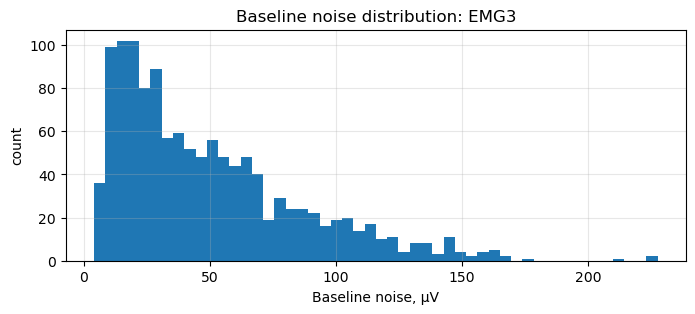

In [8]:
# baseline шума для каждой эпохи

baseline_window_ms = (-5.0, -1.0)
baseline_mask = (times_ms >= baseline_window_ms[0]) & (times_ms <= baseline_window_ms[1])

if not baseline_mask.any():
    raise ValueError("Baseline window не попал во временную ось epochs_auto")

baseline_data = epochs_data_uv[:, baseline_mask]
baseline_median_uv = np.median(baseline_data, axis=1)
baseline_noise_uv = 1.4826 * np.median(np.abs(baseline_data - baseline_median_uv[:, None]), axis=1)
baseline_df = epochs_meta.assign(baseline_median_uv=baseline_median_uv, baseline_noise_uv=baseline_noise_uv)

print("Baseline samples:", int(baseline_mask.sum()))
print("Baseline window, ms:", times_ms[baseline_mask][[0, -1]])
display(baseline_df[["baseline_median_uv", "baseline_noise_uv"]].describe())

plt.figure(figsize=(8, 3))
plt.hist(baseline_noise_uv, bins=50)
plt.xlabel("Baseline noise, µV")
plt.ylabel("count")
plt.title(f"Baseline noise distribution: {ch_name}")
plt.grid(True, alpha=0.3)
plt.show()


In [9]:
# Параметры ER (исходя из ручной разметки)

er_window_ms = (4.5, 12.0)  # окно поиска ER после стимула

er_local_noise_k = 2.5  # множитель шума этой эпохи для ER
er_global_noise_k = 2.0  # множитель общего шума записи для ER
er_min_abs_uv = 80.0  # минимальная глубина отрицательного ER

er_prom_noise_k = 1.5  # насколько ER должен выделяться над шумом

er_min_width_ms = 0.5  # минимальная длительность ER
er_max_width_ms = 3.2  # максимальная длительность ER

er_min_core_p2p_uv = 150.0  # минимум размаха центральной части ER
er_core_p2p_noise_k = 4.0  # центральный размах ER должен быть выше шума

er_core_frac = 0.50  # доля глубины для центральной части ER
er_measure_frac = 0.20  # доля глубины для полного p2p ER

er_max_prepeak_ms = 1.5  # максимум до отрицательного пика ER
er_max_postpeak_ms = 1.5  # максимум после отрицательного пика ER
er_max_measure_ms = 2.0  # окно для измерения полного размаха ER

er_allow_edge_bounds = True  # берет край окна если ER не дошел до baseline


In [10]:
# Функции ER

def er_bounds(y, peak_idx, frac, pre_ms, post_ms):  # находит начало и конец ER вокруг пика
    level = -frac * abs(y[peak_idx])
    left_limit = max(er_indices[0], peak_idx - max(1, int(round(pre_ms / dt_ms))))
    right_limit = min(er_indices[-1], peak_idx + max(1, int(round(post_ms / dt_ms))))
    left = np.where(y[left_limit:peak_idx + 1] >= level)[0]
    right = np.where(y[peak_idx:right_limit + 1] >= level)[0]
    if len(left) == 0 and not er_allow_edge_bounds:
        return None
    if len(right) == 0 and not er_allow_edge_bounds:
        return None
    left_idx = left_limit + int(left[-1]) if len(left) else left_limit
    right_idx = peak_idx + int(right[0]) if len(right) else right_limit
    return None if left_idx >= peak_idx or right_idx <= peak_idx else (left_idx, right_idx)


def empty_er(epoch_idx, stim_time_s, baseline_uv, noise_uv, depth_thr, core_thr, source):  # создаёт строку, если ER не найден
    return {
        "epoch_index": epoch_idx, "stim_time_s": stim_time_s,
        "baseline_median_uv": baseline_uv, "baseline_noise_uv": noise_uv, "global_noise_uv": global_noise_uv,
        "er_found": False, "er_start_ms": np.nan, "er_peak_ms": np.nan, "er_end_ms": np.nan,
        "er_min_uv": np.nan, "er_max_uv": np.nan, "er_depth_uv": np.nan, "er_p2p_uv": np.nan,
        "er_core_p2p_uv": np.nan, "er_width_ms": np.nan,
        "er_depth_threshold_uv": depth_thr, "er_core_p2p_threshold_uv": core_thr,
        "er_depth_noise_ratio": np.nan, "er_p2p_noise_ratio": np.nan, "er_detection_source": source,
    }


In [11]:
# Детекция ER

if "epoch_index" not in baseline_df.columns:
    baseline_df = baseline_df.assign(epoch_index=np.arange(len(baseline_df)))

er_mask = (times_ms >= er_window_ms[0]) & (times_ms <= er_window_ms[1])
if not er_mask.any():
    raise ValueError("ER window не попал во временную ось")

er_indices = np.where(er_mask)[0]
dt_ms = float(np.median(np.diff(times_ms)))
global_noise_uv = as_float(np.nanmedian(pd.to_numeric(baseline_df["baseline_noise_uv"], errors="coerce")), 1.0)
if global_noise_uv <= 0:
    global_noise_uv = 1.0
min_peak_distance = max(1, int(round(0.8 / dt_ms)))


def detect_er(epoch_idx, signal_uv, baseline_uv, noise_uv, stim_time_s):  # ищет ранний отрицательный ответ ER
    noise_uv = noise_uv if np.isfinite(noise_uv) and noise_uv > 0 else global_noise_uv
    y = signal_uv - baseline_uv
    y_er = y[er_indices]
    depth_thr = max(er_min_abs_uv, er_local_noise_k * noise_uv, er_global_noise_k * global_noise_uv)
    prom_thr = max(0.5 * er_min_abs_uv, er_prom_noise_k * noise_uv)
    core_thr = max(er_min_core_p2p_uv, er_core_p2p_noise_k * noise_uv)
    peaks, _ = find_peaks(-y_er, height=depth_thr, prominence=prom_thr, distance=min_peak_distance)
    source = "not_found"

    for peak_local in peaks:
        peak_idx = int(er_indices[int(peak_local)])
        core = er_bounds(y, peak_idx, er_core_frac, er_max_prepeak_ms, er_max_postpeak_ms)
        if core is None:
            source = "core_bounds_not_found"; continue

        left, right = core
        width_ms = float(times_ms[right] - times_ms[left])
        if width_ms < er_min_width_ms:
            source = "er_too_narrow"; continue
        if width_ms > er_max_width_ms:
            source = "er_too_wide"; continue

        core_p2p = float(np.ptp(signal_uv[left:right + 1]))
        if core_p2p < core_thr:
            source = "core_p2p_below_threshold"; continue

        measure = er_bounds(y, peak_idx, er_measure_frac, er_max_measure_ms, er_max_measure_ms) or core
        m_left, m_right = measure
        measure_wave = signal_uv[m_left:m_right + 1]
        depth_uv = float(-y[peak_idx])
        p2p_uv = float(np.ptp(measure_wave))

        return {
            "epoch_index": epoch_idx, "stim_time_s": stim_time_s,
            "baseline_median_uv": baseline_uv, "baseline_noise_uv": noise_uv, "global_noise_uv": global_noise_uv,
            "er_found": True, "er_start_ms": float(times_ms[left]), "er_peak_ms": float(times_ms[peak_idx]), "er_end_ms": float(times_ms[right]),
            "er_min_uv": float(signal_uv[peak_idx]), "er_max_uv": float(np.max(measure_wave)),
            "er_depth_uv": depth_uv, "er_p2p_uv": p2p_uv, "er_core_p2p_uv": core_p2p, "er_width_ms": width_ms,
            "er_depth_threshold_uv": depth_thr, "er_core_p2p_threshold_uv": core_thr,
            "er_depth_noise_ratio": depth_uv / noise_uv, "er_p2p_noise_ratio": p2p_uv / noise_uv,
            "er_detection_source": "first_negative_peak",
        }

    return empty_er(epoch_idx, stim_time_s, baseline_uv, noise_uv, depth_thr, core_thr, source)

baseline_lookup = baseline_df.set_index("epoch_index")
er_rows = []

for epoch_idx, signal_uv in enumerate(epochs_data_uv):
    row = baseline_lookup.loc[epoch_idx]
    stim_time_s = (epochs_auto.events[epoch_idx, 0] - raw.first_samp) / raw.info["sfreq"]
    er_rows.append(detect_er(epoch_idx, signal_uv, float(row["baseline_median_uv"]), float(row["baseline_noise_uv"]), float(stim_time_s)))

er_detect_df = pd.DataFrame(er_rows)
er_cols = [col for col in er_detect_df.columns if col not in ["epoch_index", "baseline_median_uv", "baseline_noise_uv", "stim_time_s"]]
er_df = baseline_df.drop(columns=[col for col in er_cols if col in baseline_df.columns], errors="ignore")
er_df = er_df.merge(er_detect_df.drop(columns=["baseline_median_uv", "baseline_noise_uv", "stim_time_s"], errors="ignore"), on="epoch_index", how="left")

print("Epochs:", len(er_df))
print("ER found:", int(er_df["er_found"].sum()))
print("ER missing:", int((~er_df["er_found"]).sum()))
print("ER sources:")
print(er_df["er_detection_source"].value_counts(dropna=False))


Epochs: 1240
ER found: 1221
ER missing: 19
ER sources:
er_detection_source
first_negative_peak         1221
core_p2p_below_threshold      14
not_found                      5
Name: count, dtype: int64


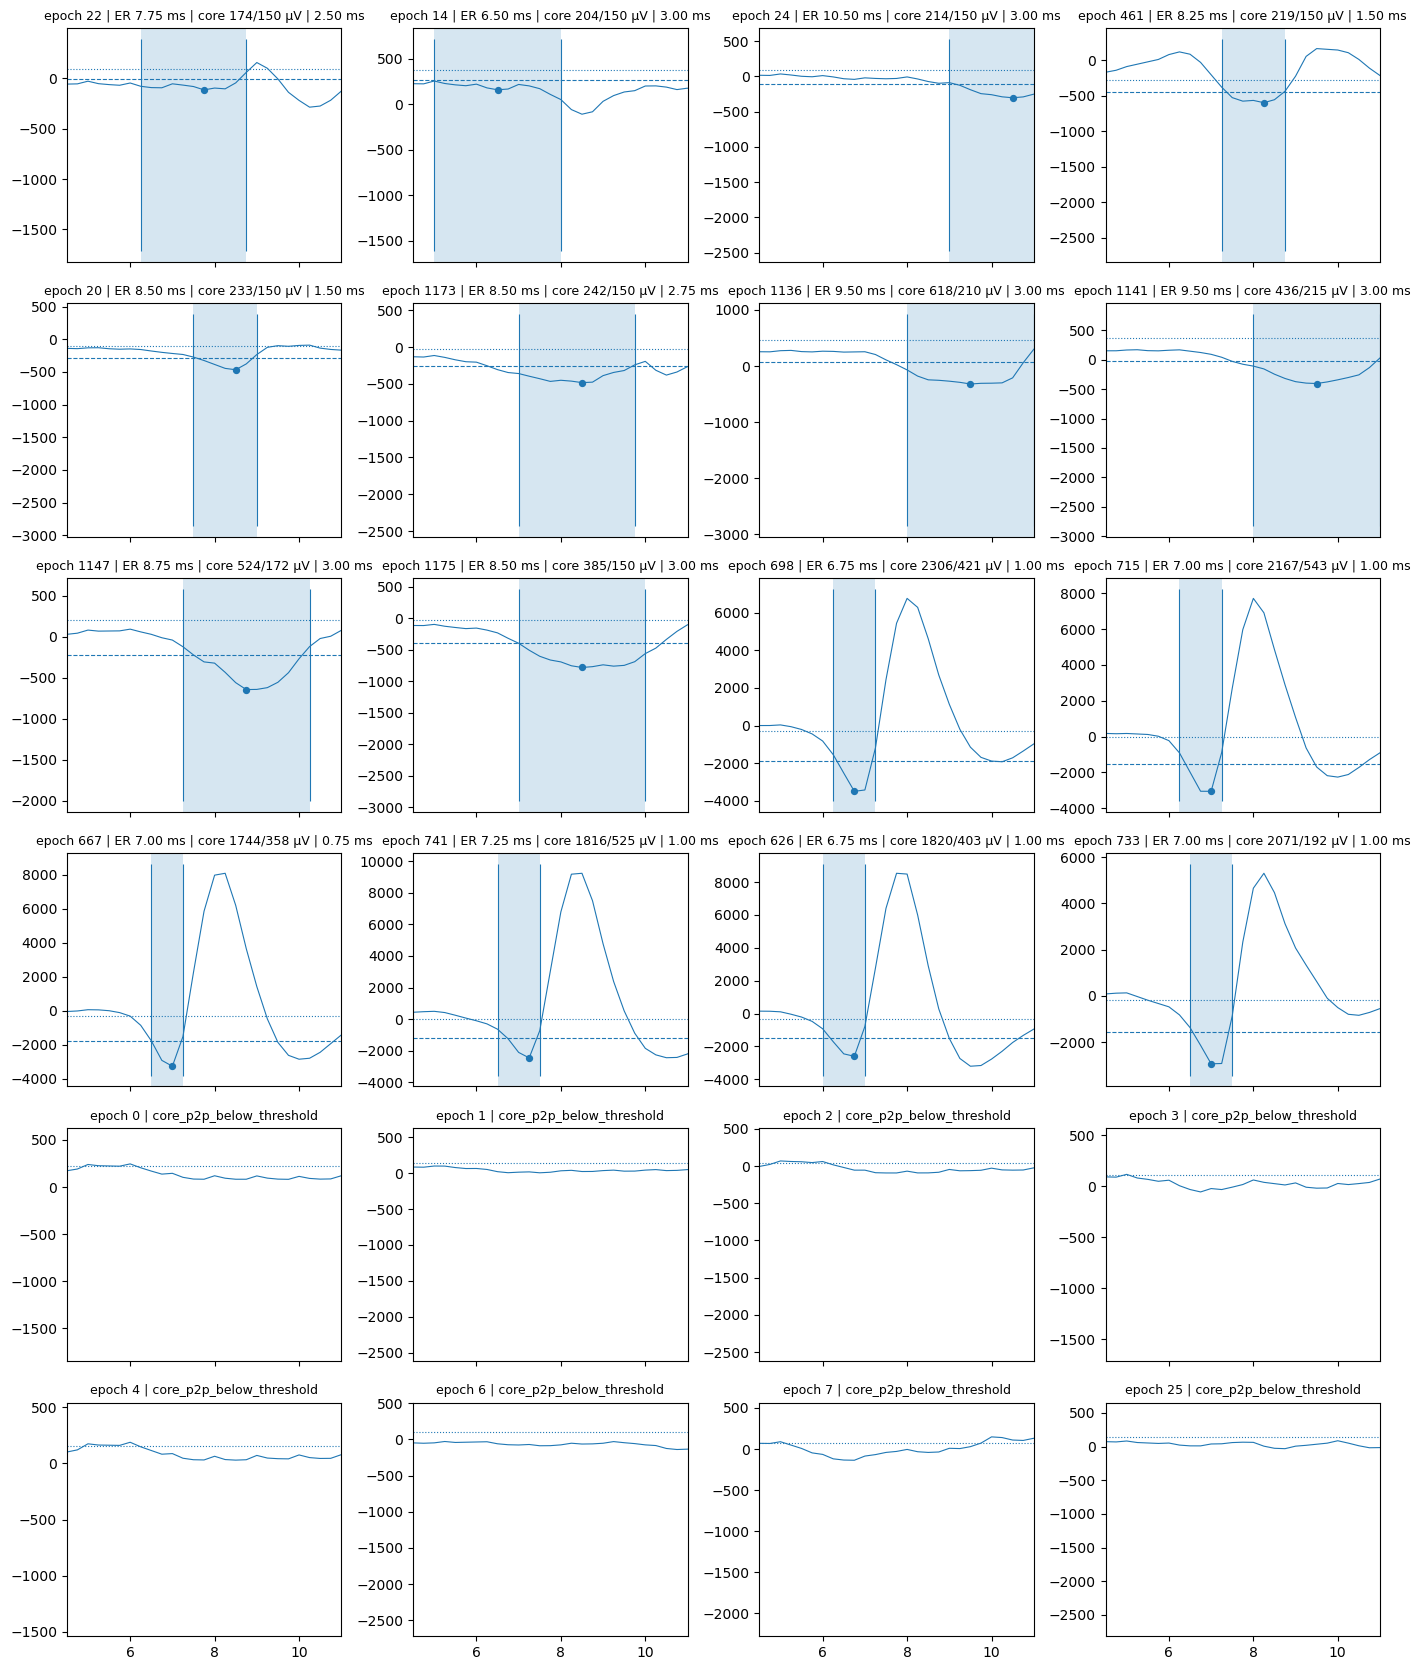

In [12]:
# Проверка ER

er_valid = er_df[er_df["er_found"]].copy()
qc_indices = list(dict.fromkeys(
    er_valid.nsmallest(6, "er_core_p2p_uv")["epoch_index"].astype(int).tolist()
    + er_valid.nlargest(6, "er_width_ms")["epoch_index"].astype(int).tolist()
    + er_valid.nlargest(6, "er_p2p_uv")["epoch_index"].astype(int).tolist()
    + er_df.loc[~er_df["er_found"], "epoch_index"].head(8).astype(int).tolist()
))

if len(qc_indices) == 0:
    print("Нет эпох для проверки")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(qc_indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.8 * n_rows), sharex=True)
    axes = np.ravel(axes)
    er_lookup = er_df.set_index("epoch_index")

    for ax, epoch_idx in zip(axes, qc_indices):
        row = er_lookup.loc[epoch_idx]
        signal_uv = epochs_data_uv[epoch_idx]
        ax.plot(times_ms, signal_uv, linewidth=0.8)
        ax.axvline(0, linestyle=":", linewidth=0.8)
        ax.axhline(row["baseline_median_uv"], linestyle=":", linewidth=0.8)

        if row["er_found"]:
            core_level_uv = row["baseline_median_uv"] - er_core_frac * row["er_depth_uv"]
            ax.axhline(core_level_uv, linestyle="--", linewidth=0.8)
            ax.axvspan(row["er_start_ms"], row["er_end_ms"], alpha=0.18)
            ax.vlines([row["er_start_ms"], row["er_end_ms"]], *ax.get_ylim(), linewidth=0.8)
            ax.scatter(row["er_peak_ms"], row["er_min_uv"], s=18)
            title = f"epoch {epoch_idx} | ER {row['er_peak_ms']:.2f} ms | core {row['er_core_p2p_uv']:.0f}/{row['er_core_p2p_threshold_uv']:.0f} µV | {row['er_width_ms']:.2f} ms"
        else:
            title = f"epoch {epoch_idx} | {row['er_detection_source']}"

        ax.set_title(title, fontsize=9)
        ax.set_xlim(4.5, 11.0)

    for ax in axes[len(qc_indices):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [13]:
# Аннотации ER

er_label = "ER_auto"
missing = [col for col in ["epoch_index", "er_found", "er_start_ms", "er_end_ms"] if col not in er_df.columns]
if missing:
    raise ValueError(f"В er_df нет колонок: {missing}")

old_ann = raw.annotations.copy()
raw.set_annotations(old_ann[np.asarray(old_ann.description) != er_label])

stim_samples = epochs_auto.events[:, 0]
sfreq = raw.info["sfreq"]
er_valid = er_df.query("er_found == True").dropna(subset=["er_start_ms", "er_end_ms"])
er_valid = er_valid[er_valid["er_end_ms"] > er_valid["er_start_ms"]]

records = []
for _, row in er_valid.iterrows():
    epoch_idx = int(row["epoch_index"])
    if 0 <= epoch_idx < len(stim_samples):
        stim_time_s = (stim_samples[epoch_idx] - raw.first_samp) / sfreq
        records.append((stim_time_s + row["er_start_ms"] / 1000, (row["er_end_ms"] - row["er_start_ms"]) / 1000))

er_annotations = mne.Annotations([r[0] for r in records], [r[1] for r in records], [er_label] * len(records))
raw.set_annotations(raw.annotations + er_annotations)

print("ER annotations:", len(er_annotations))
print("Total annotations:", len(raw.annotations))


ER annotations: 1221
Total annotations: 2468


In [14]:
# Параметры для поиска MR

mr_fixed_peak_center_ms = 8.5  # ожидаемая латентность MR-пика
mr_fixed_peak_half_window_ms = 1.0  # окно поиска MR-пика вокруг ожидаемой латентности
mr_min_amp_uv = 20.0  # минимальная высота положительного MR
mr_noise_k = 2.5  # MR должен быть выше шума
mr_er_frac = 0.03  # минимум отношения MR к ER
mr_er_reject_threshold = 1.0  # reject если MR больше ER
lr_gap_after_mr_peak_ms = 0.5  # отступ перед поиском LR после MR-пика

dt_ms = float(np.median(np.diff(times_ms)))


In [15]:
# Функции MR

def nearest_idx(t_ms):  # находит индекс ближайшего времени в эпохе
    return idx_at(times_ms, t_ms)


def row_float(row, col, default=np.nan):  # берёт числовое значение из строки таблицы
    return as_float(row.get(col, default), default)


def empty_mr(epoch_idx, reason, lr_start_ms=np.nan):  # создаёт строку, если MR не найден
    return {
        "epoch_index": epoch_idx, "mr_found": False, "mr_detection_source": reason,
        "mr_search_start_ms": np.nan, "mr_search_end_ms": np.nan,
        "mr_start_ms": np.nan, "mr_peak_ms": np.nan, "mr_end_ms": np.nan,
        "mr_peak_uv": np.nan, "mr_amp_uv": np.nan, "mr_p2p_uv": np.nan,
        "er_amp_for_mr_uv": np.nan, "mr_er_ratio": np.nan, "lr_search_start_ms": lr_start_ms,
    }


In [16]:
# Поиск MR внутри эпохи

def detect_mr(epoch_idx, row):  # ищет MR как точку локального максимума около типичной латентности
    if not bool(row.get("er_found", False)):
        return empty_mr(epoch_idx, "er_not_found")

    signal_uv = epochs_data_uv[epoch_idx]
    baseline_uv = row_float(row, "baseline_median_uv", 0.0)
    noise_uv = row_float(row, "baseline_noise_uv", 1.0)
    if not np.isfinite(noise_uv) or noise_uv <= 0:
        noise_uv = 1.0
    y = signal_uv - baseline_uv

    er_peak_ms = row_float(row, "er_peak_ms")
    er_min_uv = row_float(row, "er_min_uv")
    er_p2p_uv = row_float(row, "er_p2p_uv")

    er_amp_uv = abs(baseline_uv - er_min_uv) if np.isfinite(er_min_uv) else np.nan
    if not np.isfinite(er_amp_uv) and np.isfinite(er_p2p_uv):
        er_amp_uv = abs(er_p2p_uv)
    if not np.isfinite(er_amp_uv) and np.isfinite(er_peak_ms):
        er_amp_uv = abs(y[nearest_idx(er_peak_ms)])
    if not np.isfinite(er_amp_uv) or er_amp_uv <= 0:
        return empty_mr(epoch_idx, "bad_er_amp")

    search_start_ms = max(times_ms[0], mr_fixed_peak_center_ms - mr_fixed_peak_half_window_ms)
    search_end_ms = min(times_ms[-1], mr_fixed_peak_center_ms + mr_fixed_peak_half_window_ms)
    i0, i1 = nearest_idx(search_start_ms), nearest_idx(search_end_ms)
    fallback_lr_start_ms = mr_fixed_peak_center_ms + lr_gap_after_mr_peak_ms
    if i1 <= i0:
        return empty_mr(epoch_idx, "bad_mr_window", fallback_lr_start_ms)

    mr_peak_idx = i0 + int(np.nanargmax(y[i0:i1 + 1]))
    mr_peak_ms = float(times_ms[mr_peak_idx])
    mr_amp_uv = max(0.0, float(y[mr_peak_idx]))
    min_amp_uv = max(mr_min_amp_uv, mr_noise_k * noise_uv, mr_er_frac * er_amp_uv)
    lr_start_ms = mr_peak_ms + lr_gap_after_mr_peak_ms

    if mr_amp_uv < min_amp_uv:
        return empty_mr(epoch_idx, "mr_peak_below_threshold", lr_start_ms)

    return {
        "epoch_index": epoch_idx, "mr_found": True, "mr_detection_source": "fixed_latency_local_max",
        "mr_search_start_ms": search_start_ms, "mr_search_end_ms": search_end_ms,
        "mr_start_ms": mr_peak_ms, "mr_peak_ms": mr_peak_ms, "mr_end_ms": mr_peak_ms,
        "mr_peak_uv": float(signal_uv[mr_peak_idx]), "mr_amp_uv": mr_amp_uv, "mr_p2p_uv": 0.0,
        "er_amp_for_mr_uv": er_amp_uv, "mr_er_ratio": mr_amp_uv / er_amp_uv,
        "lr_search_start_ms": lr_start_ms,
    }


In [17]:
# Поиск MR по всей записи

if "epoch_index" not in er_df.columns:
    er_df = er_df.reset_index().rename(columns={"index": "epoch_index"})

mr_rows = [
    detect_mr(int(row["epoch_index"]), row) if 0 <= int(row["epoch_index"]) < len(epochs_data_uv) else empty_mr(int(row["epoch_index"]), "epoch_out_of_range")
    for _, row in er_df.iterrows()
]

mr_df = pd.DataFrame(mr_rows)
mr_cols = [col for col in mr_df.columns if col != "epoch_index"]
er_df = er_df.drop(columns=[col for col in mr_cols if col in er_df.columns], errors="ignore").merge(mr_df, on="epoch_index", how="left")
er_df["mr_er_ratio"] = pd.to_numeric(er_df["mr_er_ratio"], errors="coerce")
er_df["reject_mr_like"] = er_df["er_found"].fillna(False).astype(bool) & er_df["mr_found"].fillna(False).astype(bool) & er_df["mr_er_ratio"].notna() & (er_df["mr_er_ratio"] > mr_er_reject_threshold)
er_df["reject_high_mr"] = er_df["reject_mr_like"]


Epochs: 1240
ER found: 1221
MR found: 1074
MR-like reject: 867
Kept: 354
MR sources:
mr_detection_source
fixed_latency_local_max    1074
mr_peak_below_threshold     147
er_not_found                 19
Name: count, dtype: int64


,epoch_index,er_peak_ms,er_end_ms,mr_search_start_ms,mr_peak_ms,lr_search_start_ms,er_amp_for_mr_uv,mr_amp_uv,mr_er_ratio,reject_mr_like,mr_detection_source
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
5,5,6.50,7.50,7.5,9.25,9.75,686.250023,138.750001,0.202186,False,fixed_latency_local_max
6,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,er_not_found
8,8,8.50,9.25,NaN,NaN,10.00,NaN,NaN,NaN,False,mr_peak_below_threshold
9,9,7.75,8.50,7.5,9.25,9.75,791.875100,816.250009,1.030781,True,fixed_latency_local_max


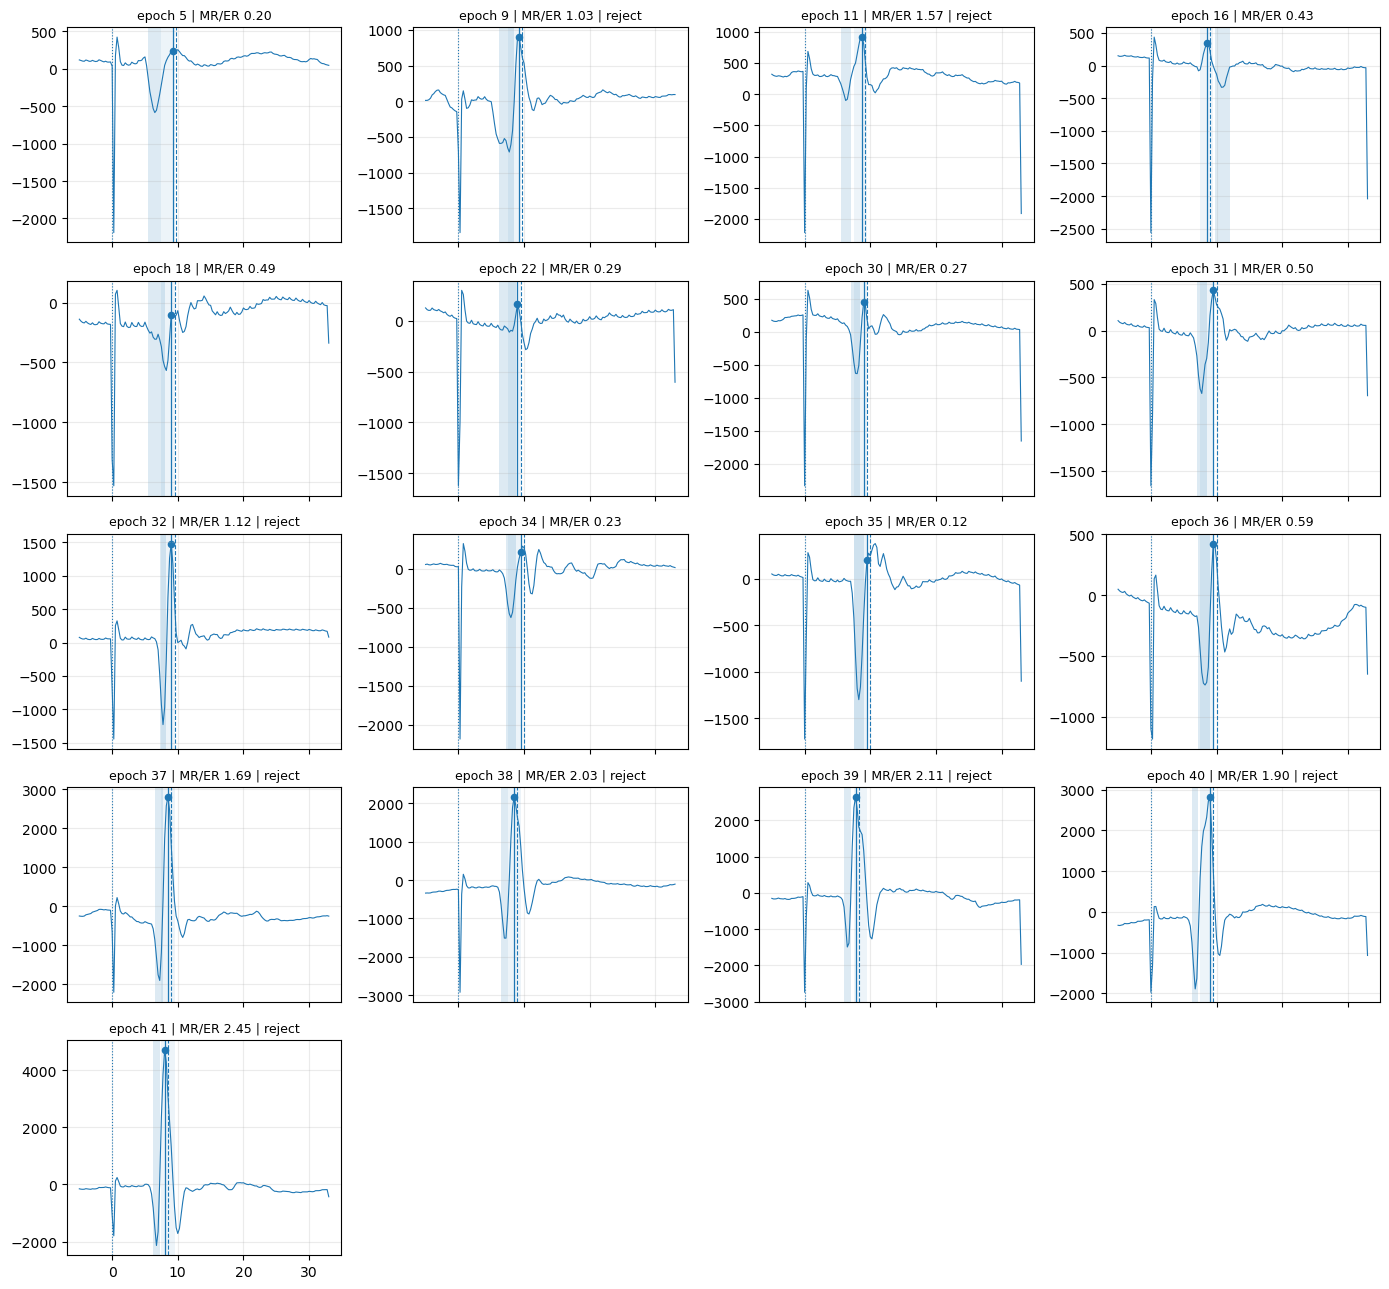

In [18]:
# Проверка MR

print("Epochs:", len(er_df))
print("ER found:", int(er_df["er_found"].sum()))
print("MR found:", int(er_df["mr_found"].sum()))
print("MR-like reject:", int(er_df["reject_mr_like"].sum()))
print("Kept:", int((er_df["er_found"] & ~er_df["reject_mr_like"]).sum()))
print("MR sources:")
print(er_df["mr_detection_source"].value_counts(dropna=False))

summary_cols = [
    "epoch_index", "er_peak_ms", "er_end_ms", "mr_search_start_ms", "mr_peak_ms", "lr_search_start_ms",
    "er_amp_for_mr_uv", "mr_amp_uv", "mr_er_ratio", "reject_mr_like", "mr_detection_source",
]
display(er_df[summary_cols].head(15))

qc_indices = list(dict.fromkeys(
    er_df.index[er_df["mr_found"]].to_list()[:12]
    + er_df.index[er_df["reject_mr_like"]].to_list()[:8]
))

if len(qc_indices) == 0:
    print("Нет эпох для проверки MR")
else:
    n_cols = 4
    n_rows = int(np.ceil(len(qc_indices) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.6 * n_rows), sharex=True)
    axes = np.ravel(axes)

    for ax, epoch_idx in zip(axes, qc_indices):
        row = er_df.loc[epoch_idx]
        signal_uv = epochs_data_uv[int(row["epoch_index"])]
        ax.plot(times_ms, signal_uv, linewidth=0.8)
        ax.axvline(0, linestyle=":", linewidth=0.8)
        ax.axvspan(row["mr_search_start_ms"], row["mr_search_end_ms"], alpha=0.08)

        if row["er_found"]:
            ax.axvspan(row["er_start_ms"], row["er_end_ms"], alpha=0.15)
        if row["mr_found"]:
            ax.axvline(row["mr_peak_ms"], linewidth=0.9)
            ax.scatter(row["mr_peak_ms"], row["mr_peak_uv"], s=20)
            ax.axvline(row["lr_search_start_ms"], linestyle="--", linewidth=0.8)

        suffix = " | reject" if row["reject_mr_like"] else ""
        ax.set_title(f"epoch {int(row['epoch_index'])} | MR/ER {row['mr_er_ratio']:.2f}{suffix}", fontsize=9)
        ax.grid(alpha=0.25)

    for ax in axes[len(qc_indices):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [19]:
# Аннотации MR

mr_label = "MR_auto"
mr_peak_annot_half_width_ms = 0.25  # короткая метка вокруг MR-пика
if len(er_df) != len(epochs_auto.events):
    raise ValueError("er_df и epochs_auto.events имеют разную длину")

old_ann = raw.annotations.copy()
raw.set_annotations(old_ann[old_ann.description != mr_label])

stim_samples = epochs_auto.events[:, 0]
sfreq = raw.info["sfreq"]
mr_valid = er_df.query("mr_found == True").dropna(subset=["mr_peak_ms"])

records = []
for _, row in mr_valid.iterrows():
    stim_time_s = (stim_samples[int(row["epoch_index"])] - raw.first_samp) / sfreq
    start_ms = row["mr_peak_ms"] - mr_peak_annot_half_width_ms
    end_ms = row["mr_peak_ms"] + mr_peak_annot_half_width_ms
    records.append((stim_time_s + start_ms / 1000, (end_ms - start_ms) / 1000))

mr_annotations = mne.Annotations([r[0] for r in records], [r[1] for r in records], [mr_label] * len(records))
raw.set_annotations(raw.annotations + mr_annotations)

print("MR annotations:", len(mr_annotations))
print("Total annotations:", len(raw.annotations))


MR annotations: 1074
Total annotations: 3542


In [20]:
# Первичный поиск LR по p2p

need("er_df", "epochs_data_uv", "times_ms", "find_peaks")

lr_raw_noise_k = 4.0  # raw LR должен иметь p2p выше шума
lr_min_abs_uv = 20.0  # минимальный размах raw LR
lr_min_ratio = 0.03  # минимум отношения raw LR к ER
lr_max_ratio = 0.80  # максимум отношения LR к ER
lr_min_wave_width_ms = 0.5  # минимальная длительность LR-волны
lr_max_wave_width_ms = 5.0  # максимальная длительность LR-волны
lr_min_separation_ms = 1.0  # минимальный интервал между LR-пиками
lr_max_per_epoch = 3  # сколько LR максимум оставить в эпохе

lr_residual_min_abs_uv = 90.0  # минимальный размах LR после вычитания ER+MR
lr_residual_min_ratio = 0.06  # минимум отношения residual LR к ER
lr_residual_p2p_noise_k = 8.0  # размах residual LR должен быть выше шума
lr_residual_prom_noise_k = 3.0  # вершина residual LR должна выделяться над шумом
lr_residual_min_peak_uv = 60.0  # минимальная высота положительного LR-пика
lr_residual_peak_noise_k = 4.0  # положительный LR-пик должен быть выше шума
lr_residual_peak_ratio = 0.035  # минимум отношения LR-пика к ER
lr_residual_duration_mode_ms = 1.625  # типичная длительность LR по распределению
lr_residual_duration_tol_ms = 1.0  # допустимое отклонение от типичной длительности

lr_fallback_gap_after_er_ms = 0.8  # fallback-отступ после ER для шаблона
lr_end_before_next_stim_ms = 2.0  # не искать LR прямо перед следующим стимулом
lr_peak_annot_half_width_ms = 0.45  # половина ширины короткой LR-аннотации

dt_ms = float(np.median(np.diff(times_ms)))
lr_min_extrema_distance = max(1, int(round(0.25 / dt_ms)))
reject_col = er_df["reject_mr_like"] if "reject_mr_like" in er_df else er_df.get("reject_high_mr", pd.Series(False, index=er_df.index))
er_df["reject_mr_like"] = reject_col.fillna(False).astype(bool)

baseline_by_epoch = er_df.set_index("epoch_index")["baseline_median_uv"].reindex(np.arange(len(epochs_data_uv))).to_numpy()
baseline_by_epoch = np.where(np.isfinite(baseline_by_epoch), baseline_by_epoch, np.nanmedian(baseline_by_epoch))
epochs_centered_uv = epochs_data_uv - baseline_by_epoch[:, None]


def finite_positive(value):  # проверяет, что значение конечное и больше нуля
    value = as_float(value)
    return np.isfinite(value) and value > 0


def lr_window(row):  # задаёт окно поиска LR от MR-пика до следующего стимула
    start_ms = as_float(row.get("lr_search_start_ms", np.nan))
    if not np.isfinite(start_ms):
        mr_peak_ms = as_float(row.get("mr_peak_ms", np.nan))
        start_ms = mr_peak_ms + lr_gap_after_mr_peak_ms if np.isfinite(mr_peak_ms) else np.nan
    isi_ms = as_float(row.get("isi_ms", np.nan))
    end_ms = min(isi_ms - lr_end_before_next_stim_ms, times_ms[-1]) if np.isfinite(isi_ms) else times_ms[-1] - lr_end_before_next_stim_ms
    return start_ms, end_ms


def lr_limits(row, method):  # считает пороги амплитуды, p2p и длительности LR
    baseline_noise = as_float(row.get("baseline_noise_uv", np.nan), np.nan)
    er_p2p = as_float(row.get("er_p2p_uv", np.nan), np.nan)
    if not np.isfinite(baseline_noise) or baseline_noise <= 0:
        baseline_noise = np.nanmedian(pd.to_numeric(er_df["baseline_noise_uv"], errors="coerce"))

    is_residual = str(method).startswith("residual")
    min_abs = lr_residual_min_abs_uv if is_residual else lr_min_abs_uv
    min_ratio = lr_residual_min_ratio if is_residual else lr_min_ratio
    noise_k = lr_residual_p2p_noise_k if is_residual else lr_raw_noise_k
    prom_k = lr_residual_prom_noise_k if is_residual else 0.5
    min_width = lr_min_wave_width_ms
    max_width = lr_max_wave_width_ms
    min_peak = 0.0

    if is_residual:
        min_width = max(lr_min_wave_width_ms, lr_residual_duration_mode_ms - lr_residual_duration_tol_ms)
        max_width = min(lr_max_wave_width_ms, lr_residual_duration_mode_ms + lr_residual_duration_tol_ms)
        min_peak = max(lr_residual_min_peak_uv, lr_residual_peak_noise_k * baseline_noise, lr_residual_peak_ratio * er_p2p)

    return {
        "baseline_noise": baseline_noise,
        "er_p2p": er_p2p,
        "min_p2p": max(min_abs, noise_k * baseline_noise, min_ratio * er_p2p),
        "max_p2p": lr_max_ratio * er_p2p,
        "prominence": max(prom_k * baseline_noise, 0.25 * min_abs),
        "min_peak": min_peak,
        "min_width": min_width,
        "max_width": max_width,
    }


def peak_window(peak_ms):  # делает короткую аннотацию вокруг вершины LR
    half_width = max(lr_peak_annot_half_width_ms, dt_ms)
    return peak_ms - half_width, peak_ms + half_width


def keep_best(candidates):  # оставляет самые сильные раздельные LR-кандидаты
    kept = []
    for cand in sorted(candidates, key=lambda x: (x["lr_noise_ratio"], x["lr_p2p_uv"]), reverse=True):
        if all(abs(cand["lr_peak_ms"] - old["lr_peak_ms"]) >= lr_min_separation_ms for old in kept):
            kept.append(cand)
        if len(kept) >= lr_max_per_epoch:
            break
    return sorted(kept, key=lambda x: x["lr_peak_ms"])


def detect_lr_p2p(epoch_idx, signal_uv, row, method):  # ищет положительные LR-пики по размаху p2p
    if bool(row.get("reject_mr_like", False)) or not bool(row.get("mr_found", False)):
        return []
    if not np.isfinite(as_float(row.get("mr_end_ms", np.nan))) or not finite_positive(row.get("er_p2p_uv", np.nan)):
        return []

    start_ms, end_ms = lr_window(row)
    if not np.isfinite(start_ms) or not np.isfinite(end_ms) or end_ms <= start_ms + lr_min_wave_width_ms:
        return []

    i0, i1 = idx_at(times_ms, start_ms), idx_at(times_ms, end_ms)
    if i1 <= i0 + 2:
        return []

    limits = lr_limits(row, method)
    segment = signal_uv[i0:i1 + 1]
    pos_peaks, _ = find_peaks(segment, prominence=limits["prominence"], distance=lr_min_extrema_distance)
    neg_peaks, _ = find_peaks(-segment, prominence=limits["prominence"], distance=lr_min_extrema_distance)
    extrema = sorted([(i0 + int(p), "max") for p in pos_peaks] + [(i0 + int(p), "min") for p in neg_peaks])
    candidates = []

    for (idx_a, type_a), (idx_b, type_b) in zip(extrema[:-1], extrema[1:]):
        if type_a == type_b:
            continue
        width_ms = float(times_ms[idx_b] - times_ms[idx_a])
        p2p_uv = float(abs(signal_uv[idx_b] - signal_uv[idx_a]))
        if width_ms < limits["min_width"] or width_ms > limits["max_width"]:
            continue
        if p2p_uv < limits["min_p2p"] or p2p_uv > limits["max_p2p"]:
            continue

        peak_idx = idx_a if type_a == "max" else idx_b
        peak_uv = float(signal_uv[peak_idx])
        if peak_uv <= limits["min_peak"]:
            continue

        peak_ms = float(times_ms[peak_idx])
        start_peak_ms, end_peak_ms = peak_window(peak_ms)
        candidates.append({
            "epoch_index": int(epoch_idx), "stim_time_s": as_float(row.get("stim_time_s", np.nan)), "method": method, "candidate_rank": 0,
            "lr_window_start_ms": float(start_ms), "lr_window_end_ms": float(end_ms),
            "lr_wave_start_ms": float(times_ms[min(idx_a, idx_b)]), "lr_wave_end_ms": float(times_ms[max(idx_a, idx_b)]), "lr_duration_ms": width_ms,
            "lr_start_ms": float(start_peak_ms), "lr_peak_ms": peak_ms, "lr_end_ms": float(end_peak_ms),
            "lr_p2p_uv": p2p_uv, "lr_peak_uv": peak_uv, "lr_ratio": p2p_uv / limits["er_p2p"],
            "lr_noise_ratio": p2p_uv / limits["baseline_noise"], "lr_peak_noise_ratio": peak_uv / limits["baseline_noise"],
            "lr_polarity": "pos_to_neg" if type_a == "max" else "neg_to_pos",
            "baseline_noise_uv": limits["baseline_noise"], "er_p2p_uv": limits["er_p2p"],
        })

    kept = keep_best(candidates)
    for rank, cand in enumerate(kept, start=1):
        cand["candidate_rank"] = rank
    return kept


raw_lr_rows = [
    cand
    for _, row in er_df.iterrows()
    for epoch_idx in [int(row["epoch_index"])]
    if 0 <= epoch_idx < len(epochs_centered_uv)
    for cand in detect_lr_p2p(epoch_idx, epochs_centered_uv[epoch_idx], row, "raw_p2p")
]

lr_candidate_cols = [
    "epoch_index", "stim_time_s", "method", "candidate_rank", "lr_window_start_ms", "lr_window_end_ms",
    "lr_wave_start_ms", "lr_wave_end_ms", "lr_duration_ms", "lr_start_ms", "lr_peak_ms", "lr_end_ms",
    "lr_p2p_uv", "lr_peak_uv", "lr_ratio", "lr_noise_ratio", "lr_peak_noise_ratio", "lr_polarity",
    "baseline_noise_uv", "er_p2p_uv",
]

lr_candidates_raw_df = pd.DataFrame(raw_lr_rows, columns=lr_candidate_cols)
lr_candidate_sensitive = set(lr_candidates_raw_df["epoch_index"].astype(int)) if len(lr_candidates_raw_df) else set()

print("Raw LR p2p detection")
print("Candidate rows:", len(lr_candidates_raw_df))
print("Epochs with possible LR:", len(lr_candidate_sensitive))

if len(lr_candidates_raw_df):
    display(lr_candidates_raw_df[["epoch_index", "candidate_rank", "lr_peak_ms", "lr_duration_ms", "lr_p2p_uv", "lr_ratio", "lr_noise_ratio", "lr_polarity"]].head(20))


Raw LR p2p detection
Candidate rows: 363
Epochs with possible LR: 179


,epoch_index,candidate_rank,lr_peak_ms,lr_duration_ms,lr_p2p_uv,lr_ratio,lr_noise_ratio,lr_polarity
0,5,1,10.00,2.75,205.625001,0.326389,23.358674,pos_to_neg
1,5,2,18.25,2.75,97.812488,0.155258,11.111344,neg_to_pos
2,5,3,26.25,3.25,86.249995,0.136905,9.797863,pos_to_neg
3,18,1,10.00,0.75,182.631898,0.451742,15.637841,pos_to_neg
4,18,2,12.00,1.25,250.424357,0.619427,21.442565,neg_to_pos
5,18,3,14.00,1.75,157.406852,0.389347,13.477949,pos_to_neg
6,30,1,12.00,2.50,305.087175,0.357044,7.759159,pos_to_neg
7,34,1,12.25,2.75,311.914308,0.481062,47.747427,pos_to_neg
8,34,2,17.25,2.25,138.893920,0.214214,21.261696,neg_to_pos
9,34,3,21.75,1.50,190.193539,0.293333,29.114574,neg_to_pos


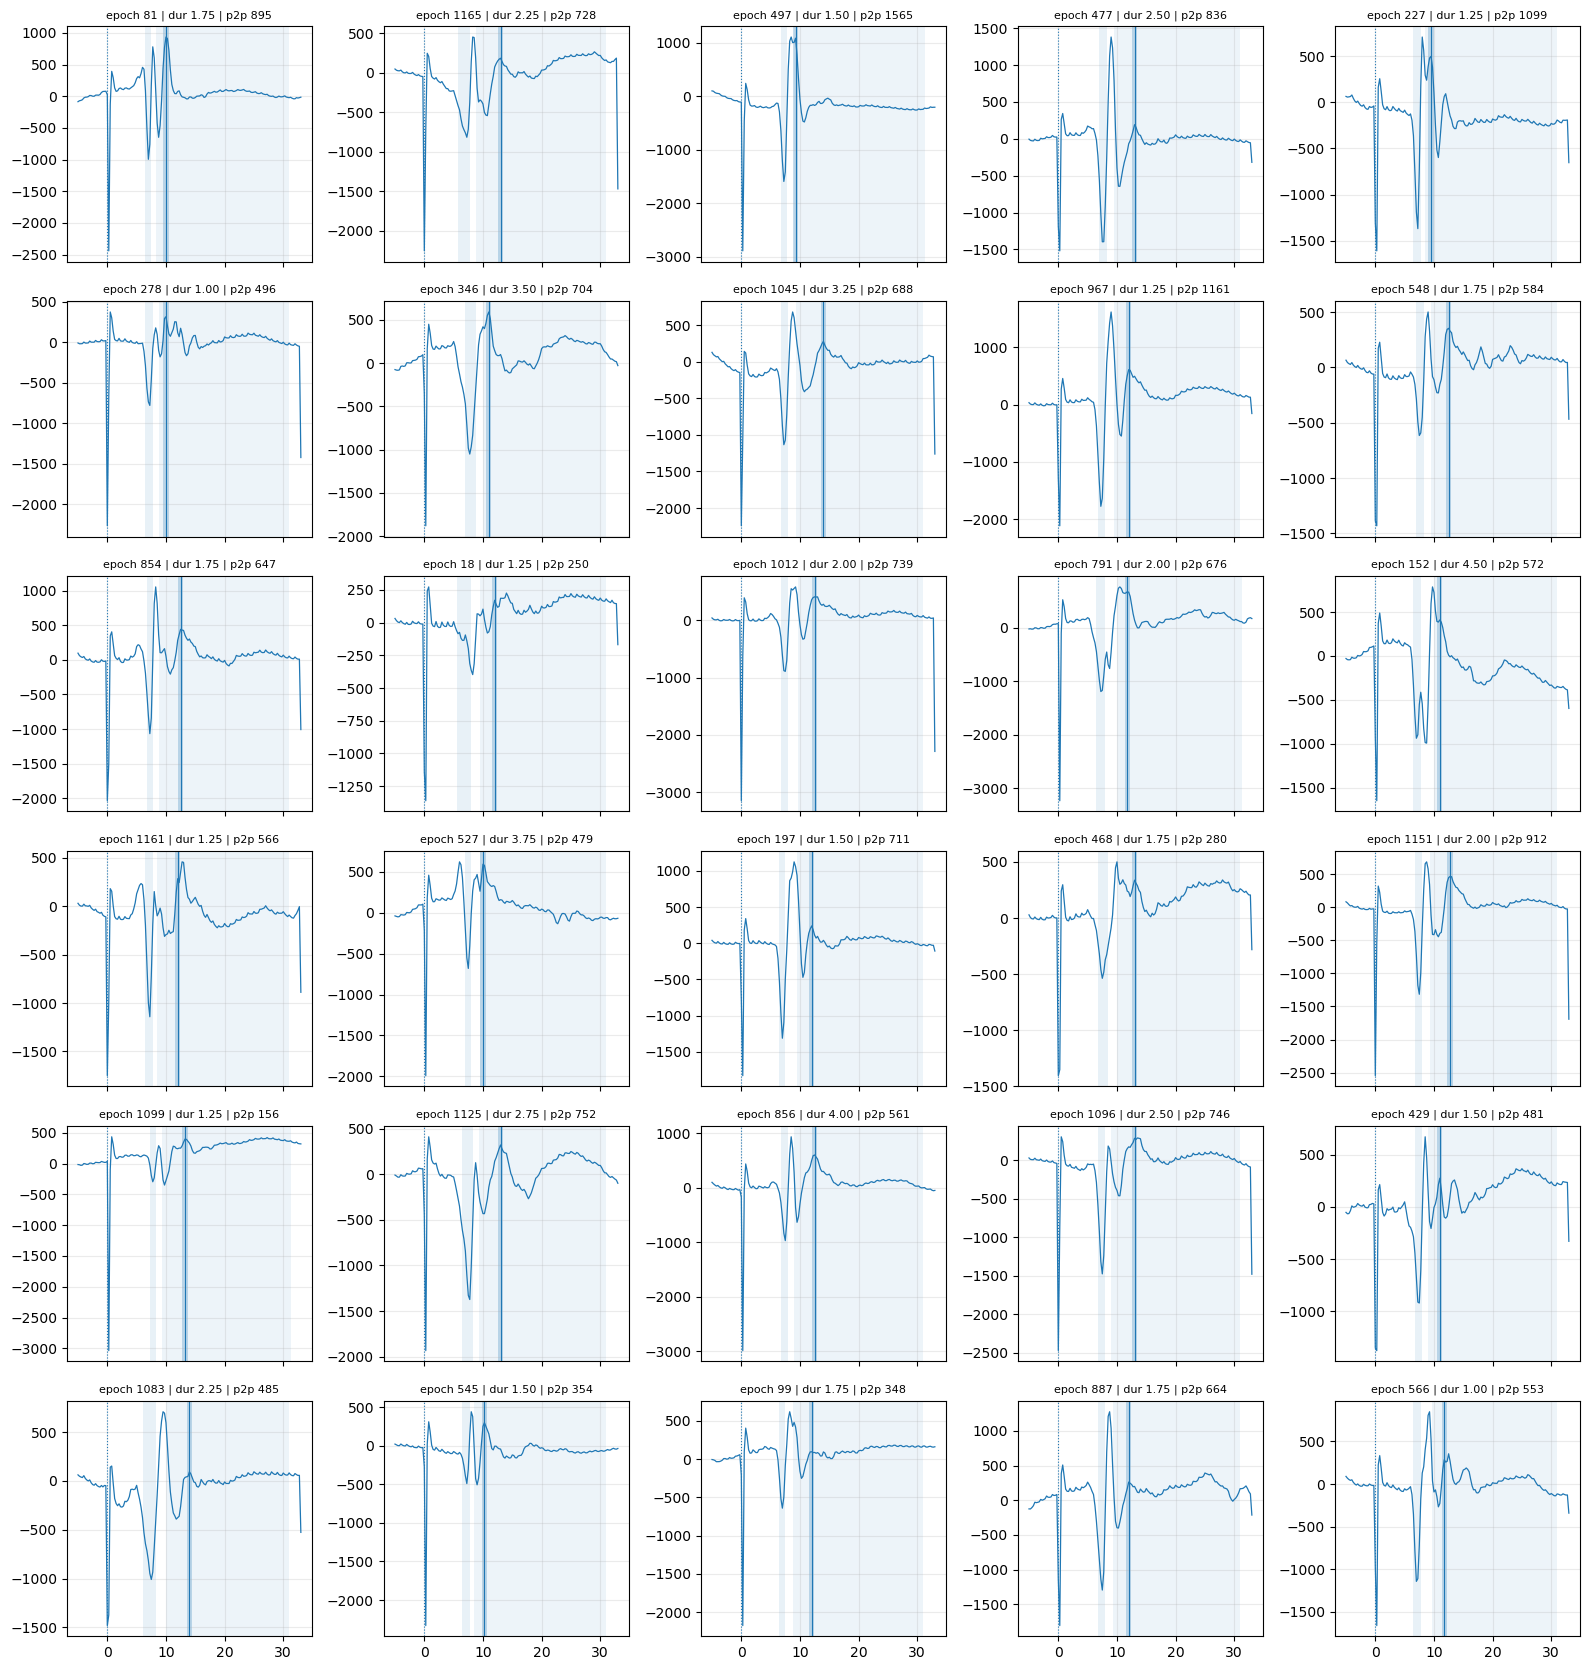

In [21]:
# Проверка первичного LR

need("lr_candidates_raw_df", "epochs_centered_uv", "times_ms")

plot_meta = lr_candidates_raw_df.sort_values(["lr_ratio", "lr_noise_ratio"], ascending=False).head(30).copy()

if len(plot_meta) == 0:
    print("Нет первичных LR-кандидатов")
else:
    n_cols = 5
    n_rows = int(np.ceil(len(plot_meta) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.8 * n_rows), sharex=True)
    axes = np.ravel(axes)

    er_lookup = er_df.set_index("epoch_index")
    for ax, (_, cand) in zip(axes, plot_meta.iterrows()):
        epoch_idx = int(cand["epoch_index"])
        row = er_lookup.loc[epoch_idx]
        ax.plot(times_ms, epochs_centered_uv[epoch_idx], linewidth=0.9)
        ax.axvline(0, linestyle=":", linewidth=0.8)
        ax.axvspan(cand["lr_window_start_ms"], cand["lr_window_end_ms"], alpha=0.08)
        ax.axvspan(cand["lr_start_ms"], cand["lr_end_ms"], alpha=0.25)
        ax.axvline(cand["lr_peak_ms"], linewidth=0.8)
        if pd.notna(row.get("er_start_ms", np.nan)) and pd.notna(row.get("er_end_ms", np.nan)):
            ax.axvspan(row["er_start_ms"], row["er_end_ms"], alpha=0.10)
        if pd.notna(row.get("mr_start_ms", np.nan)) and pd.notna(row.get("mr_end_ms", np.nan)):
            ax.axvspan(row["mr_start_ms"], row["mr_end_ms"], alpha=0.12)
        ax.set_title(f"epoch {epoch_idx} | dur {cand['lr_duration_ms']:.2f} | p2p {cand['lr_p2p_uv']:.0f}", fontsize=8)
        ax.grid(alpha=0.25)

    for ax in axes[len(plot_meta):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


In [22]:
# Шаблон ER+MR и residual LR

need("lr_candidate_sensitive", "epochs_centered_uv", "er_df", "detect_lr_p2p")

min_er_mr_epochs_for_template = 20  # минимум чистых эпох для шаблона ER+MR
fit_cols = ["er_start_ms", "er_peak_ms", "er_end_ms", "mr_peak_ms", "lr_search_start_ms"]
er_mr_mask = er_df["er_found"] & er_df["mr_found"] & ~er_df["reject_mr_like"] & er_df[fit_cols].notna().all(axis=1)
er_mr_mask &= ~er_df["epoch_index"].astype(int).isin(lr_candidate_sensitive)

er_mr_epoch_indices = er_df.loc[er_mr_mask, "epoch_index"].astype(int).to_numpy()
er_mr_template_epoch_indices = er_mr_epoch_indices
er_only_epoch_indices = er_mr_epoch_indices
er_mr_df = er_df.loc[er_mr_mask].copy().reset_index(drop=True)

if len(er_mr_epoch_indices) < min_er_mr_epochs_for_template:
    raise RuntimeError(f"Слишком мало ER+MR без LR для шаблона: {len(er_mr_epoch_indices)}")

er_mr_template_uv = np.nanmedian(epochs_centered_uv[er_mr_epoch_indices], axis=0)  # шаблон ER+MR
er_template_uv = er_mr_template_uv  # ER-шаблон


def fit_mask(row):  # выбирает участок ER+MR для подгонки шаблона
    start_ms = as_float(row.get("er_start_ms", np.nan), 4.5)
    end_ms = as_float(row.get("lr_search_start_ms", np.nan), as_float(row.get("mr_peak_ms", np.nan), as_float(row.get("er_end_ms", np.nan)) + lr_fallback_gap_after_er_ms))
    return (times_ms >= start_ms) & (times_ms <= end_ms)


def fit_alpha(epoch_uv, template_uv, row):  # подбирает масштаб шаблона ER+MR для эпохи
    mask = fit_mask(row)
    denom = float(np.dot(template_uv[mask], template_uv[mask])) if mask.sum() >= 3 else np.nan
    alpha = float(np.dot(epoch_uv[mask], template_uv[mask]) / denom) if np.isfinite(denom) and denom > 0 else 1.0
    return alpha if np.isfinite(alpha) else 1.0

alpha_by_epoch = np.ones(len(epochs_centered_uv), dtype=float)
residual_epochs_uv = np.empty_like(epochs_centered_uv)
er_lookup = er_df.set_index("epoch_index", drop=False)

for epoch_idx, epoch_uv in enumerate(epochs_centered_uv):
    row = er_lookup.loc[epoch_idx] if epoch_idx in er_lookup.index else {}
    alpha_by_epoch[epoch_idx] = fit_alpha(epoch_uv, er_mr_template_uv, row)
    residual_epochs_uv[epoch_idx] = epoch_uv - alpha_by_epoch[epoch_idx] * er_mr_template_uv

residual_lr_rows = [
    cand
    for _, row in er_df.iterrows()
    for epoch_idx in [int(row["epoch_index"])]
    if 0 <= epoch_idx < len(residual_epochs_uv)
    for cand in detect_lr_p2p(epoch_idx, residual_epochs_uv[epoch_idx], row, "residual_p2p")
]

lr_candidates_residual_df = pd.DataFrame(residual_lr_rows, columns=lr_candidate_cols)
lr_keys = [  # поля LR
    "wave_start_ms", "wave_end_ms", "duration_ms", "start_ms", "peak_ms", "end_ms",
    "p2p_uv", "peak_uv", "ratio", "noise_ratio", "peak_noise_ratio", "polarity", "method", "confidence", "confidence_score",
]


def lr_slot(cand=None):  # раскладывает LR-кандидата в колонки таблицы
    if cand is None:
        return dict(zip(lr_keys, [np.nan] * 11 + ["none", "none", "none", 0]))
    return {
        "wave_start_ms": as_float(cand["lr_wave_start_ms"]), "wave_end_ms": as_float(cand["lr_wave_end_ms"]),
        "duration_ms": as_float(cand["lr_duration_ms"]), "start_ms": as_float(cand["lr_start_ms"]),
        "peak_ms": as_float(cand["lr_peak_ms"]), "end_ms": as_float(cand["lr_end_ms"]),
        "p2p_uv": as_float(cand["lr_p2p_uv"]), "peak_uv": as_float(cand["lr_peak_uv"]),
        "ratio": as_float(cand["lr_ratio"]), "noise_ratio": as_float(cand["lr_noise_ratio"]),
        "peak_noise_ratio": as_float(cand["lr_peak_noise_ratio"]), "polarity": cand["lr_polarity"],
        "method": cand["method"], "confidence": "medium", "confidence_score": 2,
    }

records = []
for _, row in er_df.iterrows():
    epoch_idx = int(row["epoch_index"])
    epoch_lr = lr_candidates_residual_df.query("epoch_index == @epoch_idx").sort_values("candidate_rank")
    base = {
        "epoch_index": epoch_idx, "stim_time_s": as_float(row.get("stim_time_s", np.nan)), "isi_ms": as_float(row.get("isi_ms", np.nan)),
        "baseline_noise_uv": as_float(row.get("baseline_noise_uv", np.nan)),
        "er_peak_ms": as_float(row.get("er_peak_ms", np.nan)), "er_start_ms": as_float(row.get("er_start_ms", np.nan)),
        "er_end_ms": as_float(row.get("er_end_ms", np.nan)), "er_p2p_uv": as_float(row.get("er_p2p_uv", np.nan)),
        "mr_found": bool(row.get("mr_found", False)), "mr_start_ms": as_float(row.get("mr_start_ms", np.nan)),
        "mr_peak_ms": as_float(row.get("mr_peak_ms", np.nan)), "mr_end_ms": as_float(row.get("mr_end_ms", np.nan)),
        "mr_er_ratio": as_float(row.get("mr_er_ratio", np.nan)), "reject_mr_like": bool(row.get("reject_mr_like", False)),
        "n_lr_threshold": int(epoch_idx in lr_candidate_sensitive), "n_lr_residual": int(len(epoch_lr)), "n_lr": int(len(epoch_lr)),
        "epoch_status": "excluded_mr_like" if bool(row.get("reject_mr_like", False)) else ("lr_found" if len(epoch_lr) else "no_lr"),
        "template_alpha": float(alpha_by_epoch[epoch_idx]) if 0 <= epoch_idx < len(alpha_by_epoch) else np.nan,
    }

    for k in [1, 2]:
        slot = lr_slot(epoch_lr.iloc[k - 1] if k <= len(epoch_lr) else None)
        base.update({f"lr{k}_{key}": value for key, value in slot.items()})

    base["confidence_score"] = -1 if base["epoch_status"] == "excluded_mr_like" else max(int(base["lr1_confidence_score"]), int(base["lr2_confidence_score"]))
    records.append(base)

lr_candidates_df = pd.DataFrame(records)



def lr_auc_rms(epoch_idx, start_ms, end_ms, signal_source):  # считает площадь |LR| и RMS на полной LR-волне
    if not np.isfinite([start_ms, end_ms]).all() or end_ms <= start_ms:
        return np.nan, np.nan
    mask = (times_ms >= start_ms) & (times_ms <= end_ms)
    if mask.sum() < 2 or not 0 <= epoch_idx < len(signal_source):
        return np.nan, np.nan
    segment_uv = signal_source[epoch_idx, mask]
    segment_t_ms = times_ms[mask]
    auc_abs_uv_ms = float(np.trapezoid(np.abs(segment_uv), segment_t_ms))
    rms_uv = float(np.sqrt(np.mean(segment_uv ** 2)))
    return auc_abs_uv_ms, rms_uv


for k in [1, 2]:
    auc_values = []
    rms_values = []
    for _, row in lr_candidates_df.iterrows():
        epoch_idx = int(row["epoch_index"])
        start_ms = as_float(row.get(f"lr{k}_wave_start_ms", np.nan))
        end_ms = as_float(row.get(f"lr{k}_wave_end_ms", np.nan))
        auc, rms = lr_auc_rms(epoch_idx, start_ms, end_ms, residual_epochs_uv)
        auc_values.append(auc)
        rms_values.append(rms)
    lr_candidates_df[f"lr{k}_auc_abs_uv_ms"] = auc_values
    lr_candidates_df[f"lr{k}_rms_uv"] = rms_values
selected_top = (
    lr_candidates_df
    .loc[(lr_candidates_df["n_lr"] > 0) & (lr_candidates_df["reject_mr_like"] == False)]
    .assign(max_lr_ratio=lambda d: d[["lr1_ratio", "lr2_ratio"]].max(axis=1))
    .sort_values(["confidence_score", "max_lr_ratio"], ascending=[False, False])
    .head(20)
    .copy()
)

print("ER+MR template and residual LR")
print("Template epochs:", len(er_mr_epoch_indices))
print("Raw possible LR epochs:", len(lr_candidate_sensitive))
print("Residual LR rows:", len(lr_candidates_residual_df))
print("Epochs with residual LR:", int((lr_candidates_df["n_lr"] > 0).sum()))
print("residual_epochs_uv shape:", residual_epochs_uv.shape)

display(pd.DataFrame({
    "template_min_uv": [np.nanmin(er_mr_template_uv)],
    "template_max_uv": [np.nanmax(er_mr_template_uv)],
    "template_p2p_uv": [np.ptp(er_mr_template_uv)],
    "alpha_median": [np.nanmedian(alpha_by_epoch)],
}))


ER+MR template and residual LR
Template epochs: 28
Raw possible LR epochs: 179
Residual LR rows: 151
Epochs with residual LR: 98
residual_epochs_uv shape: (1240, 153)


,template_min_uv,template_max_uv,template_p2p_uv,alpha_median
0,-1627.975791,400.559269,2028.53506,0.368175


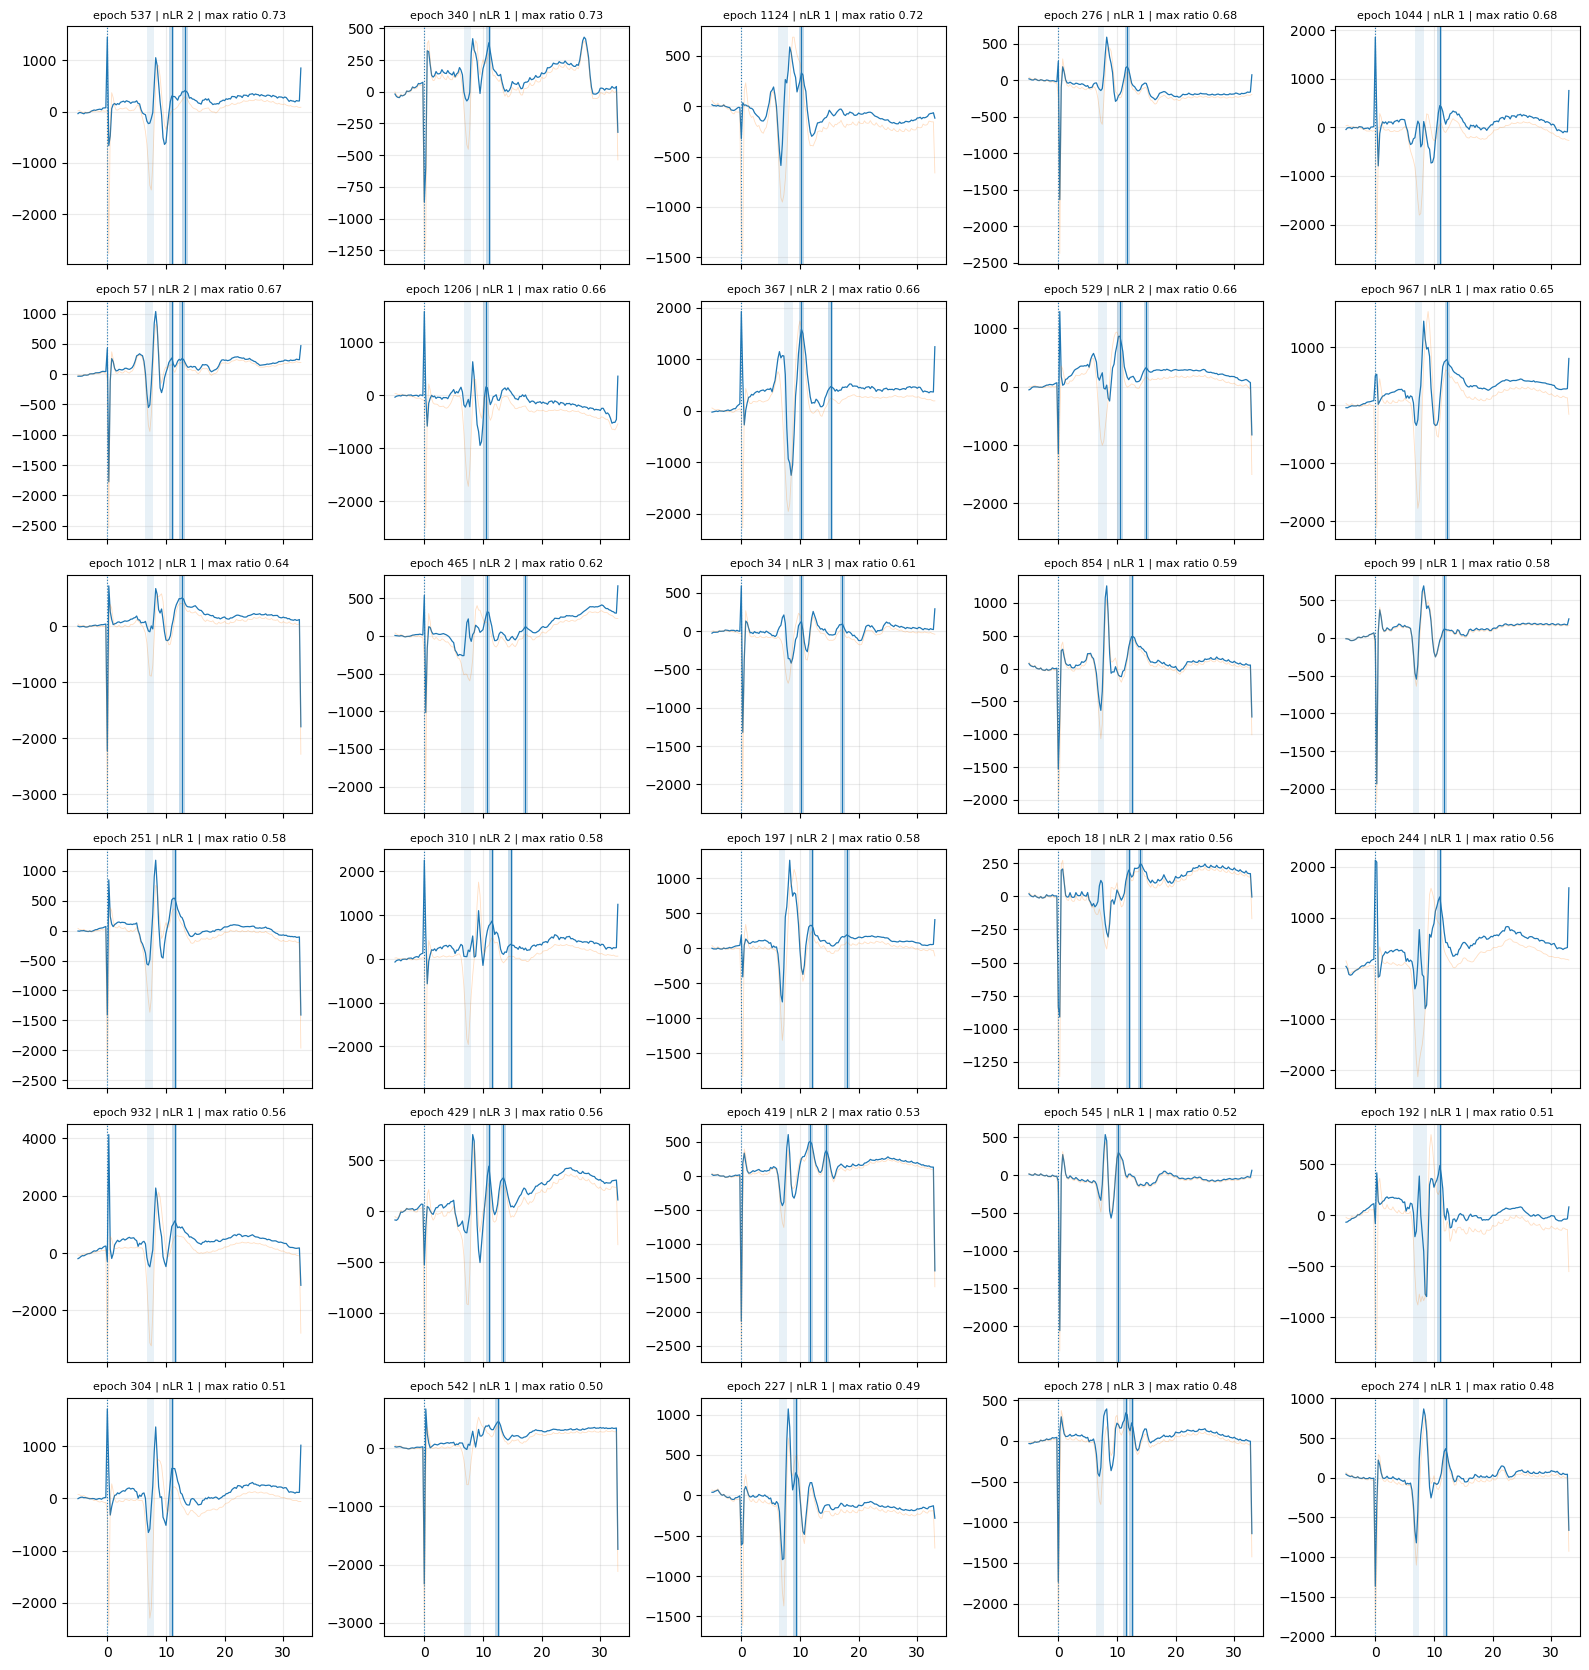

In [23]:
# Проверка residual LR

need("lr_candidates_df", "residual_epochs_uv", "epochs_centered_uv", "times_ms")

plot_meta = (
    lr_candidates_df
    .loc[(lr_candidates_df["n_lr"] > 0) & (lr_candidates_df["reject_mr_like"] == False)]
    .assign(max_lr_ratio=lambda d: d[["lr1_ratio", "lr2_ratio"]].max(axis=1))
    .sort_values(["confidence_score", "max_lr_ratio"], ascending=[False, False])
    .head(30)
    .copy()
)

if len(plot_meta) == 0:
    print("Нет residual LR")
else:
    n_cols = 5
    n_rows = int(np.ceil(len(plot_meta) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 2.8 * n_rows), sharex=True)
    axes = np.ravel(axes)

    for ax, (_, row) in zip(axes, plot_meta.iterrows()):
        epoch_idx = int(row["epoch_index"])
        ax.plot(times_ms, residual_epochs_uv[epoch_idx], linewidth=0.9)
        ax.plot(times_ms, epochs_centered_uv[epoch_idx], linewidth=0.6, alpha=0.25)
        ax.axvline(0, linestyle=":", linewidth=0.8)
        ax.axvspan(row["er_start_ms"], row["er_end_ms"], alpha=0.10)
        ax.axvspan(row["mr_start_ms"], row["mr_end_ms"], alpha=0.12)

        for k in [1, 2]:
            start_ms, end_ms, peak_ms = row.get(f"lr{k}_start_ms", np.nan), row.get(f"lr{k}_end_ms", np.nan), row.get(f"lr{k}_peak_ms", np.nan)
            if pd.notna(start_ms) and pd.notna(end_ms):
                ax.axvspan(start_ms, end_ms, alpha=0.25)
            if pd.notna(peak_ms):
                ax.axvline(peak_ms, linewidth=0.8)

        ax.set_title(f"epoch {epoch_idx} | nLR {int(row['n_lr'])} | max ratio {row['max_lr_ratio']:.2f}", fontsize=8)
        ax.grid(alpha=0.25)

    for ax in axes[len(plot_meta):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()


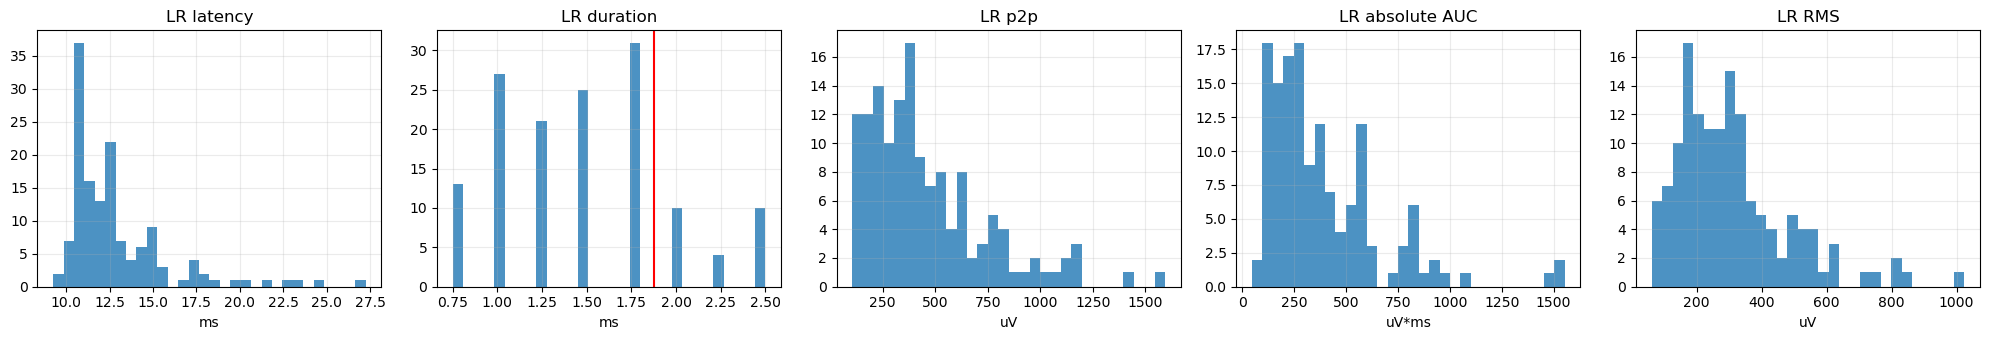

,n_lr,duration_mode_ms,duration_mode_left_ms,duration_mode_right_ms,duration_median_ms,duration_q25_ms,duration_q75_ms,auc_abs_median_uv_ms,rms_median_uv
0,141,1.875,1.75,2.0,1.5,1.0,1.75,312.056725,275.348705


,epoch_index,latency_ms,duration_ms,p2p_uv,peak_uv,noise_ratio,peak_noise_ratio,auc_abs_uv_ms,rms_uv,lr_n
31,337,9.25,0.75,404.428047,502.184422,60.204660,74.757037,209.295584,318.620554,1
51,479,11.25,0.75,237.727104,560.771219,9.616420,22.684041,355.924511,475.850112,1
52,480,10.50,0.75,196.568320,213.198237,9.515509,10.320532,115.892906,163.625060,1
115,416,12.75,0.75,264.276281,313.295293,10.465493,12.406674,115.568976,191.588179,2
123,468,13.00,0.75,134.341330,388.491167,11.027789,31.890400,239.652343,324.451301,2


In [24]:
# Распределения LR

need("lr_candidates_df")

lr_parts = []
for k in [1, 2]:
    cols = {
        f"lr{k}_peak_ms": "latency_ms", f"lr{k}_duration_ms": "duration_ms", f"lr{k}_p2p_uv": "p2p_uv",
        f"lr{k}_peak_uv": "peak_uv", f"lr{k}_noise_ratio": "noise_ratio", f"lr{k}_peak_noise_ratio": "peak_noise_ratio",
        f"lr{k}_auc_abs_uv_ms": "auc_abs_uv_ms", f"lr{k}_rms_uv": "rms_uv",
    }
    part = lr_candidates_df.loc[(lr_candidates_df["reject_mr_like"] == False) & lr_candidates_df[f"lr{k}_peak_ms"].notna(), ["epoch_index", *cols.keys()]].rename(columns=cols)
    part["lr_n"] = k
    lr_parts.append(part)

lr_distribution_df = pd.concat(lr_parts, ignore_index=True) if lr_parts else pd.DataFrame()
duration_values = lr_distribution_df["duration_ms"].dropna().to_numpy() if len(lr_distribution_df) else np.array([])
bin_step_ms = max(0.25, float(dt_ms))

if len(duration_values):
    duration_bins = np.arange(0, np.nanmax(duration_values) + 2 * bin_step_ms, bin_step_ms)
    duration_counts, duration_edges = np.histogram(duration_values, bins=duration_bins)
    mode_i = int(np.argmax(duration_counts))
    lr_duration_mode_ms = float((duration_edges[mode_i] + duration_edges[mode_i + 1]) / 2)
    lr_duration_mode_window_ms = (float(duration_edges[mode_i]), float(duration_edges[mode_i + 1]))
else:
    lr_duration_mode_ms = np.nan
    lr_duration_mode_window_ms = (np.nan, np.nan)

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
plot_specs = [
    ("latency_ms", "LR latency", "ms"),
    ("duration_ms", "LR duration", "ms"),
    ("p2p_uv", "LR p2p", "uV"),
    ("auc_abs_uv_ms", "LR absolute AUC", "uV*ms"),
    ("rms_uv", "LR RMS", "uV"),
]

for ax, (col, title, xlabel) in zip(axes, plot_specs):
    ax.hist(lr_distribution_df[col].dropna() if len(lr_distribution_df) else [], bins=30, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(alpha=0.25)

if np.isfinite(lr_duration_mode_ms):
    axes[1].axvline(lr_duration_mode_ms, color="red", linewidth=1.5)

plt.tight_layout()
plt.show()

display(pd.DataFrame({
    "n_lr": [len(lr_distribution_df)], "duration_mode_ms": [lr_duration_mode_ms],
    "duration_mode_left_ms": [lr_duration_mode_window_ms[0]], "duration_mode_right_ms": [lr_duration_mode_window_ms[1]],
    "duration_median_ms": [np.nanmedian(duration_values) if len(duration_values) else np.nan],
    "duration_q25_ms": [np.nanpercentile(duration_values, 25) if len(duration_values) else np.nan],
    "duration_q75_ms": [np.nanpercentile(duration_values, 75) if len(duration_values) else np.nan],
    "auc_abs_median_uv_ms": [np.nanmedian(lr_distribution_df["auc_abs_uv_ms"]) if len(lr_distribution_df) else np.nan],
    "rms_median_uv": [np.nanmedian(lr_distribution_df["rms_uv"]) if len(lr_distribution_df) else np.nan],
}))

lr_distribution_df.sort_values("duration_ms").head()


In [25]:
# Аннотации LR

need("raw", "epochs_auto", "lr_candidates_df", "mne")

lr_labels_to_replace = {"LR_auto", "LR_auto_high", "LR_auto_medium", "LR_auto_low", "LR_auto_threshold", "LR_auto_residual", "LR_auto_threshold_residual"}  # старые LR-метки
annotate_mr_like_lr = False  # добавлять LR в эпохах с высоким MR
min_confidence_score_to_annotate = 1  # минимальный балл LR для аннотаций

sfreq = raw.info["sfreq"]
raw_first_samp = getattr(raw, "first_samp", 0)
old_ann = raw.annotations
keep = [not (str(desc) in lr_labels_to_replace or str(desc).startswith("LR_auto")) for desc in old_ann.description]
kept_ann = mne.Annotations(np.asarray(old_ann.onset)[keep], np.asarray(old_ann.duration)[keep], np.asarray(old_ann.description)[keep], orig_time=old_ann.orig_time)
label_by_confidence = {"high": "LR_auto_high", "medium": "LR_auto_medium", "low": "LR_auto_low"}  # метки по confidence

records = []
for _, row in lr_candidates_df.iterrows():
    if int(row.get("n_lr", 0)) == 0:
        continue
    if bool(row.get("reject_mr_like", False)) and not annotate_mr_like_lr:
        continue
    if int(row.get("confidence_score", 0)) < min_confidence_score_to_annotate:
        continue

    epoch_idx = int(row["epoch_index"])
    if not 0 <= epoch_idx < len(epochs_auto.events):
        continue

    stim_time_s = (epochs_auto.events[epoch_idx, 0] - raw_first_samp) / sfreq
    for k in [1, 2]:
        start_ms, peak_ms, end_ms = [as_float(row.get(f"lr{k}_{col}", np.nan)) for col in ["start_ms", "peak_ms", "end_ms"]]
        confidence = str(row.get(f"lr{k}_confidence", "none"))
        if confidence == "none" or not np.isfinite([start_ms, peak_ms, end_ms]).all() or end_ms <= start_ms:
            continue
        onset = stim_time_s + start_ms / 1000
        if 0 <= onset <= raw.times[-1]:
            records.append((onset, (end_ms - start_ms) / 1000, label_by_confidence.get(confidence, "LR_auto")))

if records:
    onset, duration, description = zip(*records)
    lr_annotations = mne.Annotations(list(onset), list(duration), list(description), orig_time=old_ann.orig_time)
    raw.set_annotations(kept_ann + lr_annotations)
else:
    lr_annotations = mne.Annotations([], [], [], orig_time=old_ann.orig_time)
    raw.set_annotations(kept_ann)

desc = pd.Series(raw.annotations.description)
print("LR annotations:", len(lr_annotations))
print("LR_auto_high:", int((desc == "LR_auto_high").sum()))
print("LR_auto_medium:", int((desc == "LR_auto_medium").sum()))
print("LR_auto_low:", int((desc == "LR_auto_low").sum()))

raw.annotations


LR annotations: 141
LR_auto_high: 0
LR_auto_medium: 141
LR_auto_low: 0


<Annotations | 3683 segments: ER_auto (1221), LR_auto_medium (141), ...>

Эпох для графиков: 10
Ранжирование: max_lr_ratio


,epoch_index,stim_time_s,er_p2p_uv,mr_peak_ms,mr_er_ratio,reject_mr_like,n_lr,lr1_peak_ms,lr1_duration_ms,lr1_ratio,lr1_p2p_uv,lr2_peak_ms,lr2_duration_ms,lr2_ratio,lr2_p2p_uv,confidence_score
537,537,17.89375,1296.839881,8.75,0.586634,False,2,11.00,1.25,0.728449,944.681463,13.25,1.25,0.144981,188.017098,2
340,340,11.24950,550.053107,8.75,0.887435,False,1,11.00,1.50,0.726968,399.870805,NaN,NaN,NaN,NaN,2
1124,1124,37.36300,876.645987,8.75,0.717972,False,1,10.25,1.75,0.718142,629.556175,NaN,NaN,NaN,NaN,2
276,276,9.13400,698.078016,8.50,0.742867,False,1,11.75,2.00,0.682438,476.395085,NaN,NaN,NaN,NaN,2
1044,1044,34.71850,1744.971196,8.75,0.153861,False,1,11.00,1.50,0.677164,1181.631214,NaN,NaN,NaN,NaN,2
57,57,1.89475,855.798819,8.25,0.873063,False,2,11.00,1.75,0.668424,572.036520,12.75,1.25,0.164737,140.981706,2
1206,1206,40.07325,1671.465085,8.50,0.178805,False,1,10.50,1.00,0.661223,1105.210515,NaN,NaN,NaN,NaN,2
367,367,12.20800,2178.523966,9.50,0.683101,False,2,10.25,1.75,0.660780,1439.524492,15.25,1.50,0.179341,390.698836,2
529,529,17.62950,1133.343583,9.50,0.843542,False,2,10.50,1.50,0.656590,744.142519,15.00,1.75,0.216861,245.777788,2
967,967,32.17350,1742.330976,9.00,0.910692,False,1,12.25,2.00,0.654856,1140.975218,NaN,NaN,NaN,NaN,2


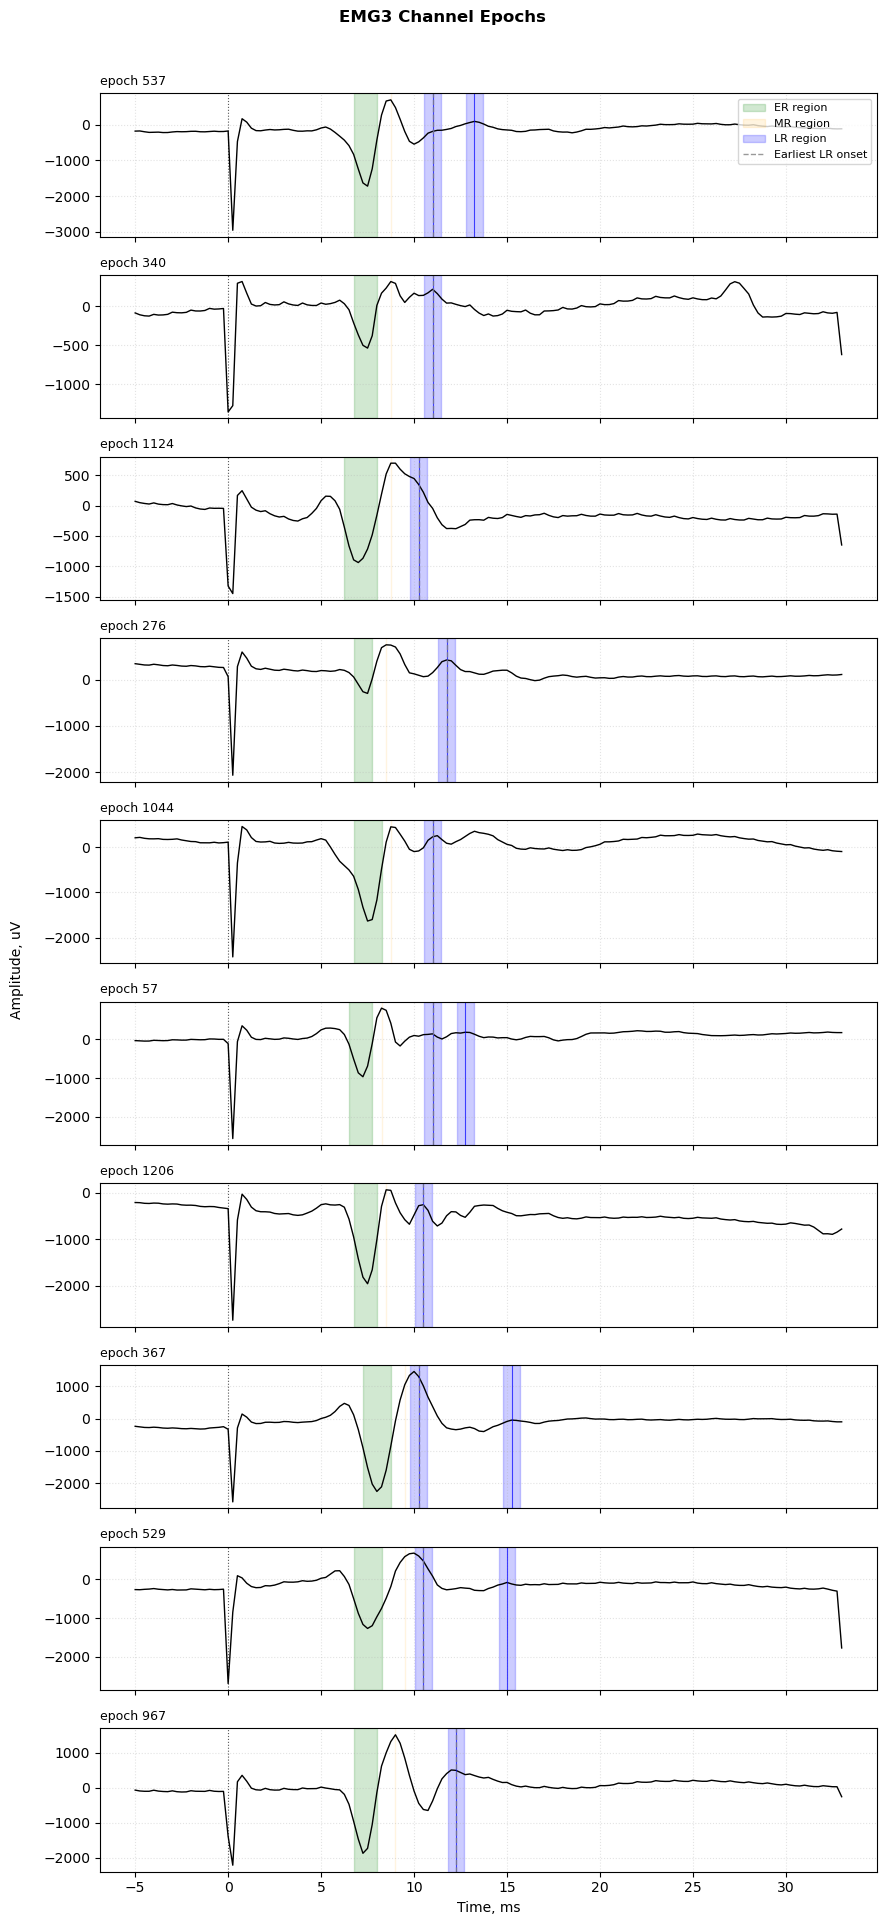

Channels marked as bad:
none


In [26]:
# Финальные графики LR

need("lr_candidates_df", "epochs_data_uv", "times_ms")

n_plots = 10  # сколько эпох показать
min_confidence_score_to_plot = 1  # минимальный балл LR для графиков
rank_by = "ratio"  # сортировать графики по LR/ER или p2p
show_reject_mr_like = True  # показывать эпохи с высоким MR

plot_meta = lr_candidates_df.copy()
reject_col = plot_meta["reject_mr_like"] if "reject_mr_like" in plot_meta else plot_meta.get("reject_high_mr", pd.Series(False, index=plot_meta.index))
plot_meta["reject_mr_like"] = reject_col.fillna(False).astype(bool)
plot_meta["has_ER"] = plot_meta["er_start_ms"].notna() & plot_meta["er_end_ms"].notna() & (plot_meta["er_p2p_uv"] > 0)
mr_found = plot_meta["mr_found"].fillna(False).astype(bool) if "mr_found" in plot_meta else pd.Series(True, index=plot_meta.index)
plot_meta["has_MR"] = mr_found & plot_meta["mr_start_ms"].notna() & plot_meta["mr_end_ms"].notna()
plot_meta["has_LR"] = (plot_meta["n_lr"] > 0) & (plot_meta["lr1_peak_ms"].notna() | plot_meta["lr2_peak_ms"].notna())
plot_meta["max_lr_ratio"] = plot_meta[["lr1_ratio", "lr2_ratio"]].max(axis=1)
plot_meta["max_lr_p2p_uv"] = plot_meta[["lr1_p2p_uv", "lr2_p2p_uv"]].max(axis=1)

rank_col = "max_lr_ratio" if rank_by == "ratio" else "max_lr_p2p_uv"
mask = plot_meta["has_ER"] & plot_meta["has_MR"] & plot_meta["has_LR"] & (plot_meta["confidence_score"] >= min_confidence_score_to_plot)
if not show_reject_mr_like:
    mask &= ~plot_meta["reject_mr_like"]

top_meta = plot_meta.loc[mask].replace([np.inf, -np.inf], np.nan).dropna(subset=[rank_col]).sort_values(["confidence_score", rank_col], ascending=[False, False]).head(n_plots).copy()
print("Эпох для графиков:", len(top_meta))
print("Ранжирование:", rank_col)

display_cols = [
    "epoch_index", "stim_time_s", "er_p2p_uv", "mr_peak_ms", "mr_er_ratio", "reject_mr_like", "n_lr",
    "lr1_peak_ms", "lr1_duration_ms", "lr1_ratio", "lr1_p2p_uv", "lr2_peak_ms", "lr2_duration_ms", "lr2_ratio", "lr2_p2p_uv", "confidence_score",
]
display(top_meta[[col for col in display_cols if col in top_meta.columns]])

if len(top_meta) == 0:
    print("Нет эпох с ER, MR и LR для построения")
else:
    fig, axes = plt.subplots(len(top_meta), 1, figsize=(9, max(2.0 * len(top_meta), 4)), sharex=True, squeeze=False)
    axes = axes[:, 0]

    for plot_idx, (_, row) in enumerate(top_meta.iterrows()):
        ax = axes[plot_idx]
        epoch_idx = int(row["epoch_index"])
        signal = epochs_data_uv[epoch_idx]
        ax.plot(times_ms, signal, color="black", lw=1.0)
        ax.axvline(0, color="black", linestyle=":", lw=0.8, alpha=0.6)

        spans = [
            (row.get("er_start_ms", np.nan), row.get("er_end_ms", np.nan), "green", 0.18, "ER region"),
            (row.get("mr_start_ms", np.nan), row.get("mr_end_ms", np.nan), "orange", 0.12, "MR region"),
        ]
        for start_ms, end_ms, color, alpha, label in spans:
            if pd.notna(start_ms) and pd.notna(end_ms):
                ax.axvspan(float(start_ms), float(end_ms), color=color, alpha=alpha, label=label if plot_idx == 0 else None)

        lr_peaks = []
        for k in [1, 2]:
            start_ms, end_ms, peak_ms = [row.get(f"lr{k}_{col}", np.nan) for col in ["start_ms", "end_ms", "peak_ms"]]
            if pd.notna(start_ms) and pd.notna(end_ms):
                ax.axvspan(float(start_ms), float(end_ms), color="blue", alpha=0.20, label="LR region" if plot_idx == 0 and k == 1 else None)
            if pd.notna(peak_ms):
                lr_peaks.append(float(peak_ms))
                ax.axvline(float(peak_ms), color="blue", lw=0.8, alpha=0.7)

        if lr_peaks:
            ax.axvline(min(lr_peaks), color="gray", linestyle="--", lw=1.0, alpha=0.8, label="Earliest LR onset" if plot_idx == 0 else None)

        ax.set_title(f"epoch {epoch_idx}", fontsize=9, loc="left")
        ax.grid(True, linestyle=":", alpha=0.35)
        if plot_idx == 0:
            ax.legend(fontsize=8, loc="upper right")

    axes[-1].set_xlabel("Time, ms")
    fig.text(0.02, 0.5, "Amplitude, uV", va="center", rotation="vertical")
    fig.suptitle(f"{globals().get('ch_name', 'EMG')} Channel Epochs", fontsize=12, weight="bold")
    plt.tight_layout(rect=[0.04, 0.02, 1, 0.97])
    plt.show()
